## This is an evaluation notebook

In [1]:
import numpy as np
from PIL import Image   
import matplotlib.pyplot as plt
import glob
from os.path import join as opj
from transformers import AutoProcessor, CLIPModel
import torch
import tqdm
import numpy as np
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
# %pip install transformers --upgrade

In [3]:
sub = "subj07"

difference_pairs=[("man","woman"),("indoor scene","outdoor scene"),("day","night"),("summer","winter"),("sad","happy"),("cat","dog"), ("still", "moving"), ("left","right"), ("top","down"), ("crowded","empty")]


In [4]:
## Load the training images
base_path="/home/matteo/brain-diffuser/data"
timeseries_path=opj(base_path,"nsddata_timeseries")
betas_path=opj(base_path,"nsddata_betas")

stimuli_path=opj(base_path,"nsddata_stimuli","stimuli","nsd")
stim_file_path=opj(stimuli_path,"nsd_stimuli.hdf5")
mod="func1pt8mm"
subj_data_path=opj(timeseries_path,"ppdata",sub,mod,"timeseries")
subj_betas_path=opj(betas_path,"ppdata",sub,mod,"betas_assumehrf")

subj_betas_roi_extracted_path=opj(base_path,"processed_roi",sub,mod)

stim_order_path=opj(base_path,"nsddata","experiments","nsd","nsd_expdesign.mat")
stim_info_path=opj(base_path,"nsddata","experiments","nsd","nsd_stim_info_merged.csv")
stim_captions_train_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_train2017.json")
stim_captions_val_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_val2017.json")

processed_data=opj(base_path,"processed_data",sub)
sub_idx=int(sub.split("0")[-1])



train_imgs=np.load(opj(processed_data,f"nsd_train_stim_sub{sub_idx}.npy")).astype(np.uint8)
# train_fmri= np.load(fmri_train_data)


In [5]:
unrolled_concepts=  [item for pair in difference_pairs for item in pair]


In [6]:
# thrs = [0,25,50,75,90,95]
thrs = [0,25]
original_coords = (1550, 150, 1760,410)
stim_coords = (370, 150, 370+210 ,410)
minus_seven = (605, 150, 605+210 ,410)
minus_five = (840, 150, 840+210 ,410)
minus_three = (1075, 150, 1075+210 ,410)
minus_one = (1315, 150, 1315+210 ,410)
plus_one = (1790, 150, 1790+210 ,410)
plus_three = (2025, 150, 2025+210 ,410)
plus_five = (2260, 150, 2260+210 ,410)
plus_seven = (2495, 150, 2495+210 ,410)

results_dir = f"models/{sub}"


# all_results={}
# for thr in thrs:
#     print("Threshold: ", thr)
#     all_results[thr] = dict()
#     for pair in tqdm.tqdm(unrolled_concepts):
#         all_results[thr][pair] = dict()

#         algebra_dir = f"{results_dir}/encoding/algebra_l2_SINGLE_thr_{thr}/fmri/{pair}_thr_{thr}"
#         # print(len(glob.glob(opj(algebra_dir,"*.png"))))
#         images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(len(glob.glob(opj(algebra_dir,"*.png")))-1)]

#         ## crop all images and fill the dict with list of images
#         all_results[thr][pair]["original"] = [img.crop(original_coords) for img in images]
#         all_results[thr][pair]["stim"] = [img.crop(stim_coords) for img in images]
#         all_results[thr][pair]["minus_seven"] = [img.crop(minus_seven) for img in images]
#         all_results[thr][pair]["minus_five"] = [img.crop(minus_five) for img in images]
#         all_results[thr][pair]["minus_three"] = [img.crop(minus_three) for img in images]
#         all_results[thr][pair]["minus_one"] = [img.crop(minus_one) for img in images]
#         all_results[thr][pair]["plus_one"] = [img.crop(plus_one) for img in images]
#         all_results[thr][pair]["plus_three"] = [img.crop(plus_three) for img in images]
#         all_results[thr][pair]["plus_five"] = [img.crop(plus_five) for img in images]
#         all_results[thr][pair]["plus_seven"] = [img.crop(plus_seven) for img in images]

        




In [7]:
## IMPORTANTE: DEVO AVERE L'IMMAGINE -7,-5,-3-,1, 0 ,1,3,5,7 (9 embeddings)

In [8]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and processor
discriminator = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Thresholds and coordinate values
thrs = [0, 25, 50, 75, 90, 95]
# thrs = [0,25]
original_coords = (1550, 150, 1760, 410)
stim_coords = (370, 150, 370+210, 410)
coords_list = {
    "minus_seven": (605, 150, 605+210, 410),
    "minus_five": (840, 150, 840+210, 410),
    "minus_three": (1075, 150, 1075+210, 410),
    "minus_one": (1315, 150, 1315+210, 410),
    "original": original_coords,  # Include original coordinates
    "plus_one": (1790, 150, 1790+210, 410),
    "plus_three": (2025, 150, 2025+210, 410),
    "plus_five": (2260, 150, 2260+210, 410),
    "plus_seven": (2495, 150, 2495+210, 410)
}

T = 0.1 

# Initialize results dictionary
all_results = {}
with torch.no_grad():
    for thr in thrs:
        print(f"Processing threshold: {thr}")
        all_results[thr] = dict()
        for pair in unrolled_concepts:  # You should have this defined with your concept pairs
            all_results[thr][pair] = dict()

            algebra_dir = f"{results_dir}/encoding/algebra_l2_SINGLE_thr_{thr}/fmri/{pair}_thr_{thr}"
            images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(len(glob.glob(opj(algebra_dir,"*.png")))-1)]

            # Encode the original image
            original_img = images[0].crop(original_coords)
            inputs = processor(images=[original_img], return_tensors="pt", padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            original_img_embeds = discriminator.get_image_features(inputs["pixel_values"]).cpu()
            original_img_embeds_norm = torch.nn.functional.normalize(original_img_embeds, p=2, dim=1)

            # Crop and process images for each coordinate, including the original
            for key, coords in coords_list.items():
                cropped_images = [img.crop(coords) for img in images]

                # Encode images with CLIP
                img_embeds = []
                BS = 128
                with torch.no_grad():
                    for batch_idx in tqdm.trange(0, len(cropped_images)//BS+1, 1):
                        batch = cropped_images[batch_idx*BS:(batch_idx+1)*BS]
                        inputs = processor(images=batch, return_tensors="pt", padding=True)
                        inputs = {k: v.to(device) for k, v in inputs.items()}
                        emb = discriminator.get_image_features(inputs["pixel_values"]).cpu()
                        img_embeds.append(emb)

                img_embeds = torch.cat(img_embeds, 0)
                all_results[thr][pair][key] = img_embeds

            # Compute text embeddings
            inputs = processor(text=[pair], return_tensors="pt", padding=True)
            txt_embeds = discriminator.get_text_features(inputs["input_ids"].to(device)).cpu()

            # Calculate similarities and store results
            for key in coords_list.keys():
                img_embeds = all_results[thr][pair][key]

                # Normalize the embeddings
                img_embeds_norm = torch.nn.functional.normalize(img_embeds, p=2, dim=1)
                txt_embeds_norm = torch.nn.functional.normalize(txt_embeds, p=2, dim=1)
                
                # Compute cosine similarity with text
                cosine_sim = img_embeds_norm @ txt_embeds_norm.T
                
                # Compute cosine similarity with the original image
                original_img_cosine_sim = img_embeds_norm @ original_img_embeds_norm.T
                
                # Concatenate similarities horizontally
                combined_cosine_sim = torch.cat((cosine_sim, original_img_cosine_sim), dim=1)
                
                # Apply softmax to obtain probabilities
                # probs = torch.nn.functional.softmax(combined_cosine_sim/T, dim=1)
                
                all_results[thr][pair][key] = combined_cosine_sim.numpy()


/home/matteo/anaconda3/envs/huggingface_v2/lib/python3.11/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/matteo/anaconda3/envs/huggingface_v2/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Processing threshold: 0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.47it/s]


Processing threshold: 25


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.26it/s]


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.23it/s]


Processing threshold: 90


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.21it/s]


Processing threshold: 95


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.73it/s]


## Load all images in training set, compute CLIP embeddings, compute baseline cosine similarity with this images

In [9]:
base_path="/home/matteo/brain-diffuser/data"
timeseries_path=opj(base_path,"nsddata_timeseries")
betas_path=opj(base_path,"nsddata_betas")

stimuli_path=opj(base_path,"nsddata_stimuli","stimuli","nsd")
stim_file_path=opj(stimuli_path,"nsd_stimuli.hdf5")
mod="func1pt8mm"
subj_data_path=opj(timeseries_path,"ppdata",sub,mod,"timeseries")
subj_betas_path=opj(betas_path,"ppdata",sub,mod,"betas_assumehrf")

subj_betas_roi_extracted_path=opj(base_path,"processed_roi",sub,mod)

stim_order_path=opj(base_path,"nsddata","experiments","nsd","nsd_expdesign.mat")
stim_info_path=opj(base_path,"nsddata","experiments","nsd","nsd_stim_info_merged.csv")
stim_captions_train_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_train2017.json")
stim_captions_val_path=opj(base_path,"nsddata_stimuli","stimuli","nsd","annotations",f"captions_val2017.json")

processed_data=opj(base_path,"processed_data",sub)
sub_idx=int(sub.split("0")[-1])

fmri_train_data=opj(processed_data,f"nsd_train_fmriavg_nsdgeneral_sub{sub_idx}.npy")


train_imgs=np.load(opj(processed_data,f"nsd_train_stim_sub{sub_idx}.npy")).astype(np.uint8)




In [10]:
## encode all the images in batch with clip
BS=128

train_img_embeds=[]
with torch.no_grad():
    for batch_idx in tqdm.trange(0,len(train_imgs)//BS+1,1):
        batch = train_imgs[batch_idx*BS:(batch_idx+1)*BS]
        batch = [Image.fromarray(i) for i in batch]
        
        # apply processor
        inputs = processor(images=batch, return_tensors="pt", padding=True)
        inputs = {k:v.to(device) for k,v in inputs.items()}
        emb = discriminator.get_image_features(inputs["pixel_values"]).cpu()
        train_img_embeds.append(emb)
        
train_img_embeds = torch.cat(train_img_embeds,0)
        

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:35<00:00,  1.98it/s]


In [11]:
import random
indices = random.sample(range(len(train_img_embeds)), 100)
sampled_embeds = train_img_embeds[indices]

In [12]:
sampled_embeds.shape

torch.Size([100, 512])

In [13]:

# Initialize results dictionary
results_dir = f"models/{sub}"

baselines = {}
base_thr= 0
with torch.no_grad():
    
    
    ## LAVORARE QUA, VOGLIO LA SIMILARITà MEDIA TRA OGNI IMMAGINE E 100 RANDOM IMAGES E PER OGNI CONCETTO CON 100 RANDOM CONCEPTS

        for pair in tqdm.tqdm(unrolled_concepts):  # You should have this defined with your concept pairs
            baselines[pair] = dict()

            algebra_dir = f"{results_dir}/encoding/algebra_l2_SINGLE_thr_{base_thr}/fmri/{pair}_thr_{base_thr}"
            images = [Image.open(f"{algebra_dir}/algebra_{i}.png") for i in range(len(glob.glob(opj(algebra_dir,"*.png")))-1)]

            # Encode the original image
            original_img =  [img.crop(original_coords) for img in images]
            inputs = processor(images=original_img, return_tensors="pt", padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            original_img_embeds = discriminator.get_image_features(inputs["pixel_values"]).cpu()
            original_img_embeds_norm = torch.nn.functional.normalize(original_img_embeds, p=2, dim=1)
            
            ## sample 100 random images from train_img_embeds
            indices = random.sample(range(len(train_img_embeds)), 100)
            sampled_embeds = train_img_embeds[indices]
            sampled_embeds_norm = torch.nn.functional.normalize(sampled_embeds, p=2, dim=1)

            #just do cosine similarity
            baseline_sim = (original_img_embeds_norm@sampled_embeds_norm.T)
            baselines[pair]["baseline_img_similarities_mean"] = baseline_sim.mean(1)
            baselines[pair]["baseline_img_similarities_std"] = baseline_sim.std(1)
            
            # Compute text embeddings
            inputs = processor(text=[pair], return_tensors="pt", padding=True)
            txt_embeds = discriminator.get_text_features(inputs["input_ids"].to(device)).cpu()
            txt_embeds_norm = torch.nn.functional.normalize(txt_embeds, p=2, dim=1)
            
            #compute text sim with embeddings
            concept_sim = (txt_embeds_norm@sampled_embeds_norm.T)
            baselines[pair]["baseline_concept_similarities_mean"] = concept_sim.mean(1)
            baselines[pair]["baseline_concept_similarities_std"] = concept_sim.std(1)
            


#             # Calculate similarities and store results
#             for key in coords_list.keys():
#                 img_embeds = all_results[thr][pair][key]

#                 # Normalize the embeddings
#                 img_embeds_norm = torch.nn.functional.normalize(img_embeds, p=2, dim=1)

#                 # Compute cosine similarity with text
#                 cosine_sim = img_embeds_norm @ txt_embeds_norm.T

#                 # Compute cosine similarity with the original image
#                 original_img_cosine_sim = img_embeds_norm @ original_img_embeds_norm.T

#                 # Concatenate similarities horizontally
#                 combined_cosine_sim = torch.cat((cosine_sim, original_img_cosine_sim), dim=1)

#                 # Apply softmax to obtain probabilities
#                 # probs = torch.nn.functional.softmax(combined_cosine_sim/T, dim=1)

#                 all_results[thr][pair][key] = combined_cosine_sim.numpy()


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.09it/s]


In [14]:
for pair in tqdm.tqdm(unrolled_concepts):
    print(baselines[pair]["baseline_img_similarities_mean"])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 3606.61it/s]

tensor([0.3726, 0.3525, 0.4226, 0.3512, 0.4352, 0.4171, 0.4284, 0.4216, 0.4371,
        0.3989, 0.4139, 0.3913, 0.3993, 0.4019, 0.4416, 0.4193, 0.4498, 0.4210,
        0.4386, 0.3898, 0.4296, 0.3802, 0.4008, 0.3975, 0.3770, 0.4088, 0.4106,
        0.3896, 0.4005, 0.4002])
tensor([0.3980, 0.4260, 0.4165, 0.4125, 0.4426, 0.4232, 0.4184, 0.4577, 0.4436,
        0.4196, 0.4446, 0.4229, 0.4228, 0.4076, 0.4376, 0.4319, 0.4307, 0.4433,
        0.4043, 0.3958, 0.4389, 0.3981, 0.4171, 0.3932, 0.4097, 0.4101, 0.4402,
        0.4037, 0.3706, 0.4030])
tensor([0.3976, 0.4020, 0.4040, 0.3755, 0.4205, 0.3756, 0.4382, 0.4273, 0.4320,
        0.4115, 0.4434, 0.3978, 0.3877, 0.4217, 0.4322, 0.3983, 0.4406, 0.4343,
        0.4295, 0.3940, 0.4457, 0.3940, 0.4304, 0.4124, 0.4185, 0.4021, 0.4135,
        0.3978, 0.3332, 0.3969])
tensor([0.3584, 0.3979, 0.4413, 0.3780, 0.4365, 0.4389, 0.4434, 0.4382, 0.4603,
        0.4050, 0.4618, 0.4195, 0.4118, 0.4079, 0.4431, 0.4333, 0.4428, 0.4354,
        0.4470, 0.402

In [15]:
# all_results[thr][pair][key]

In [30]:
all_results.keys()

dict_keys([0, 25, 50, 75, 90, 95])

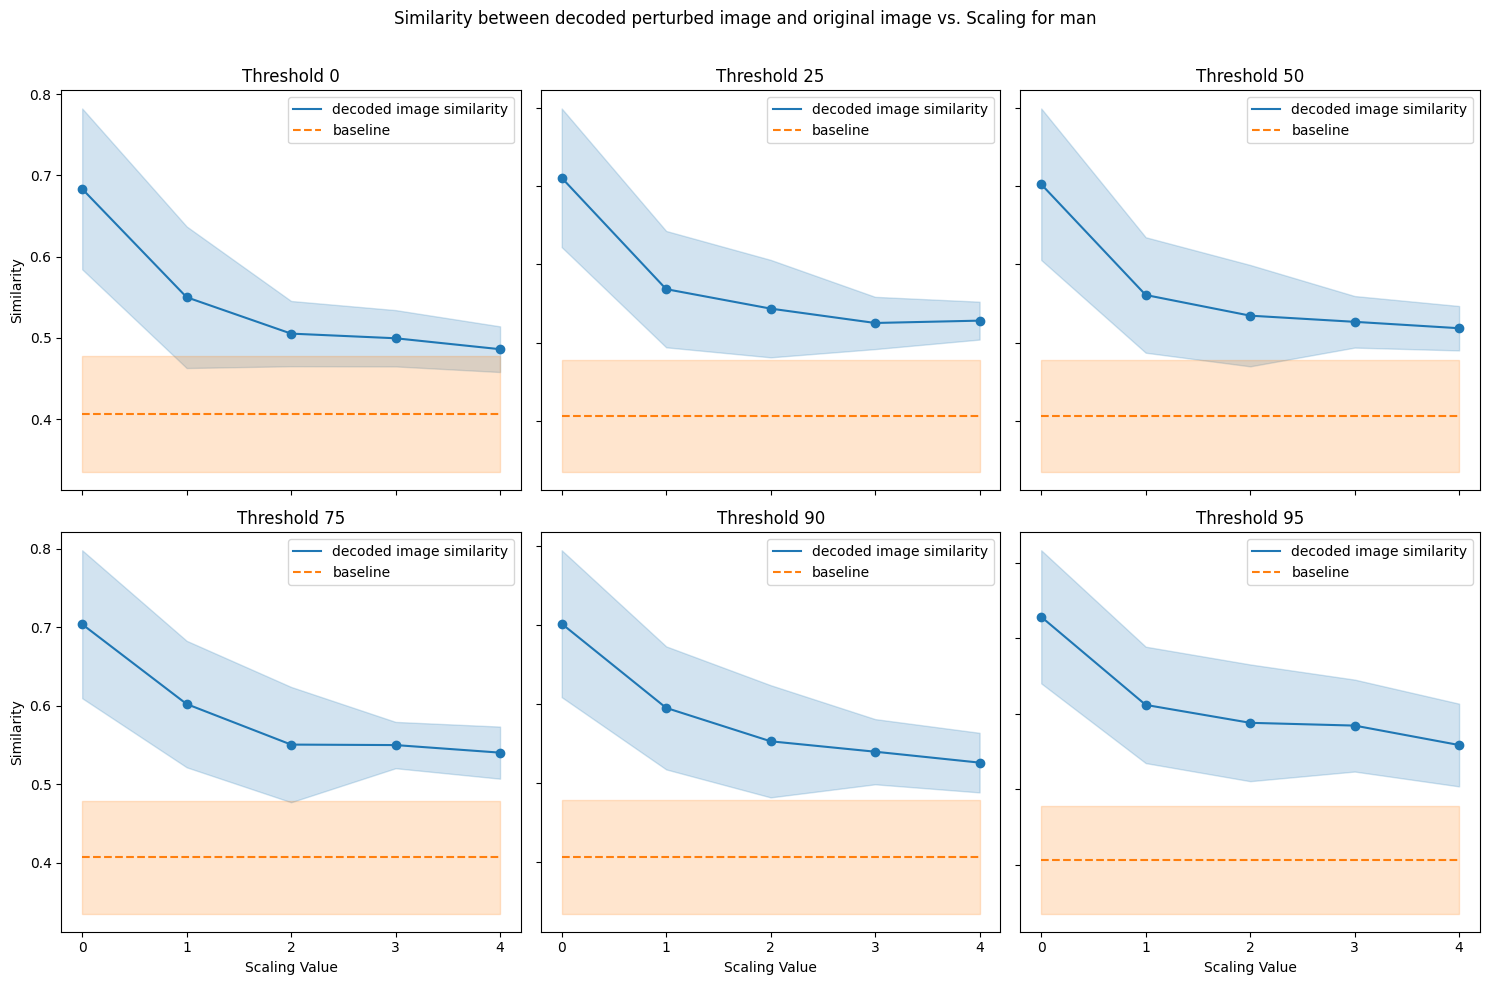

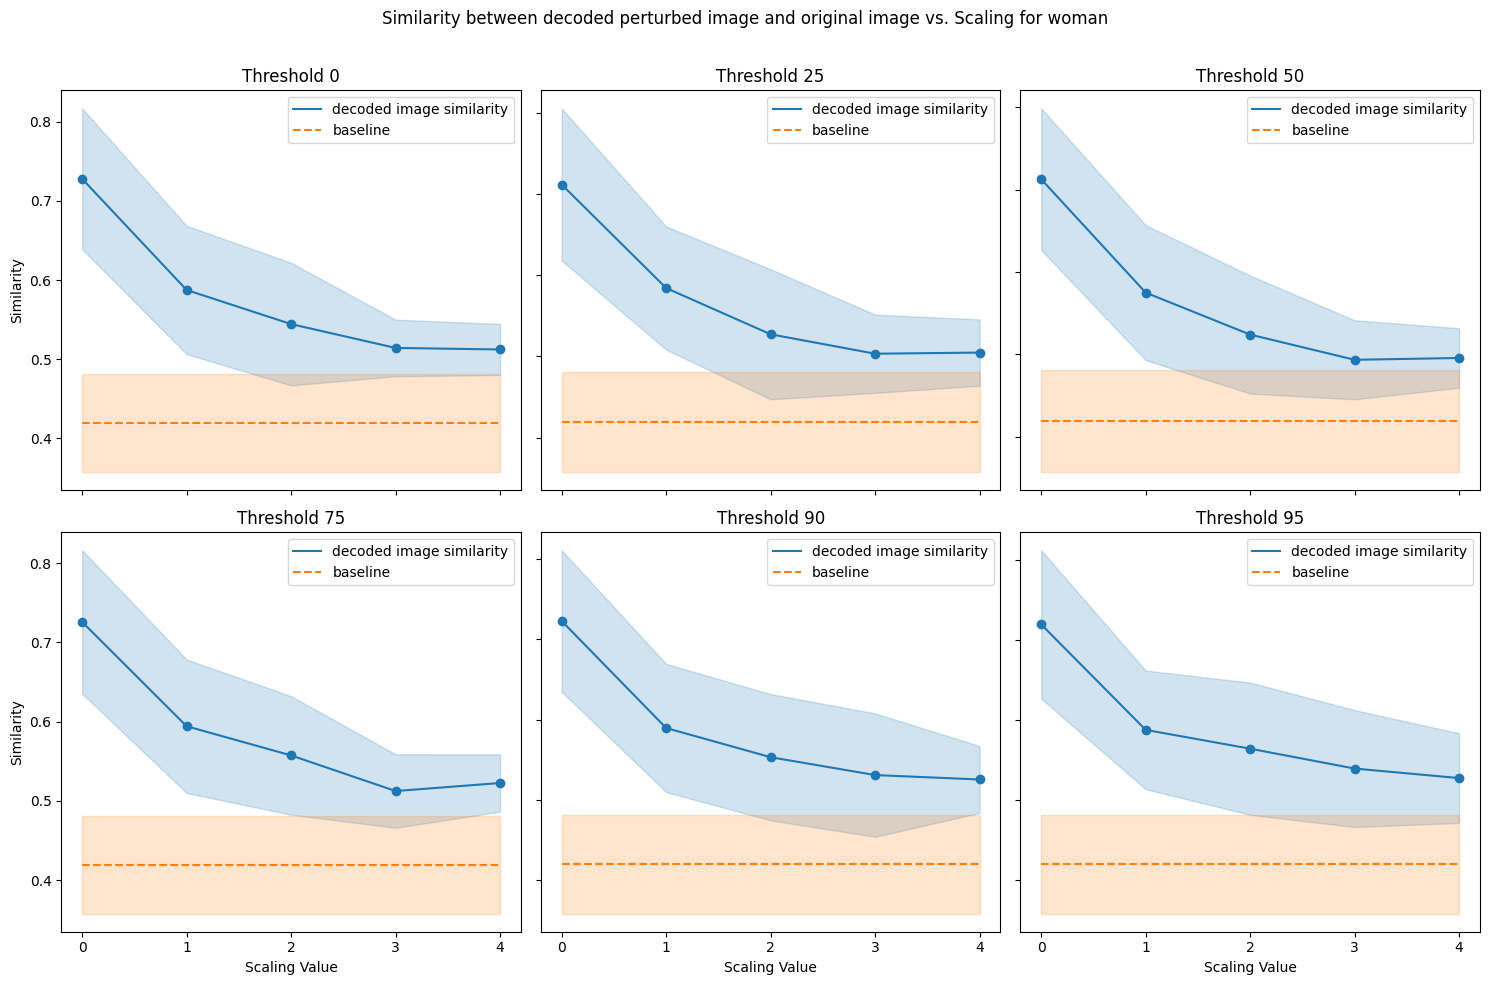

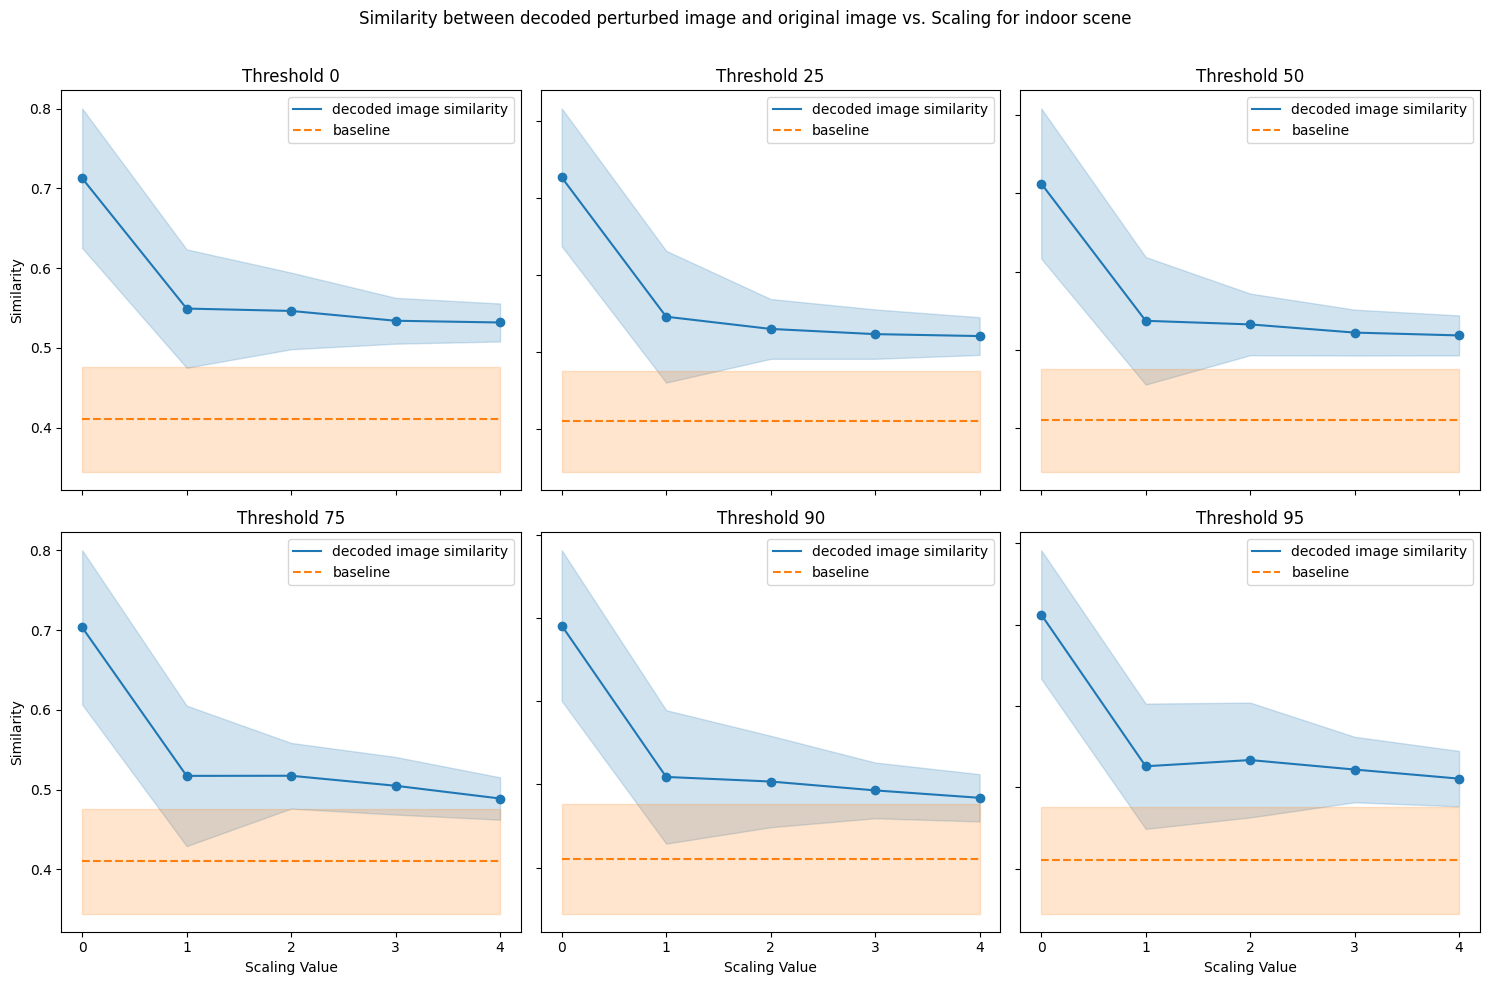

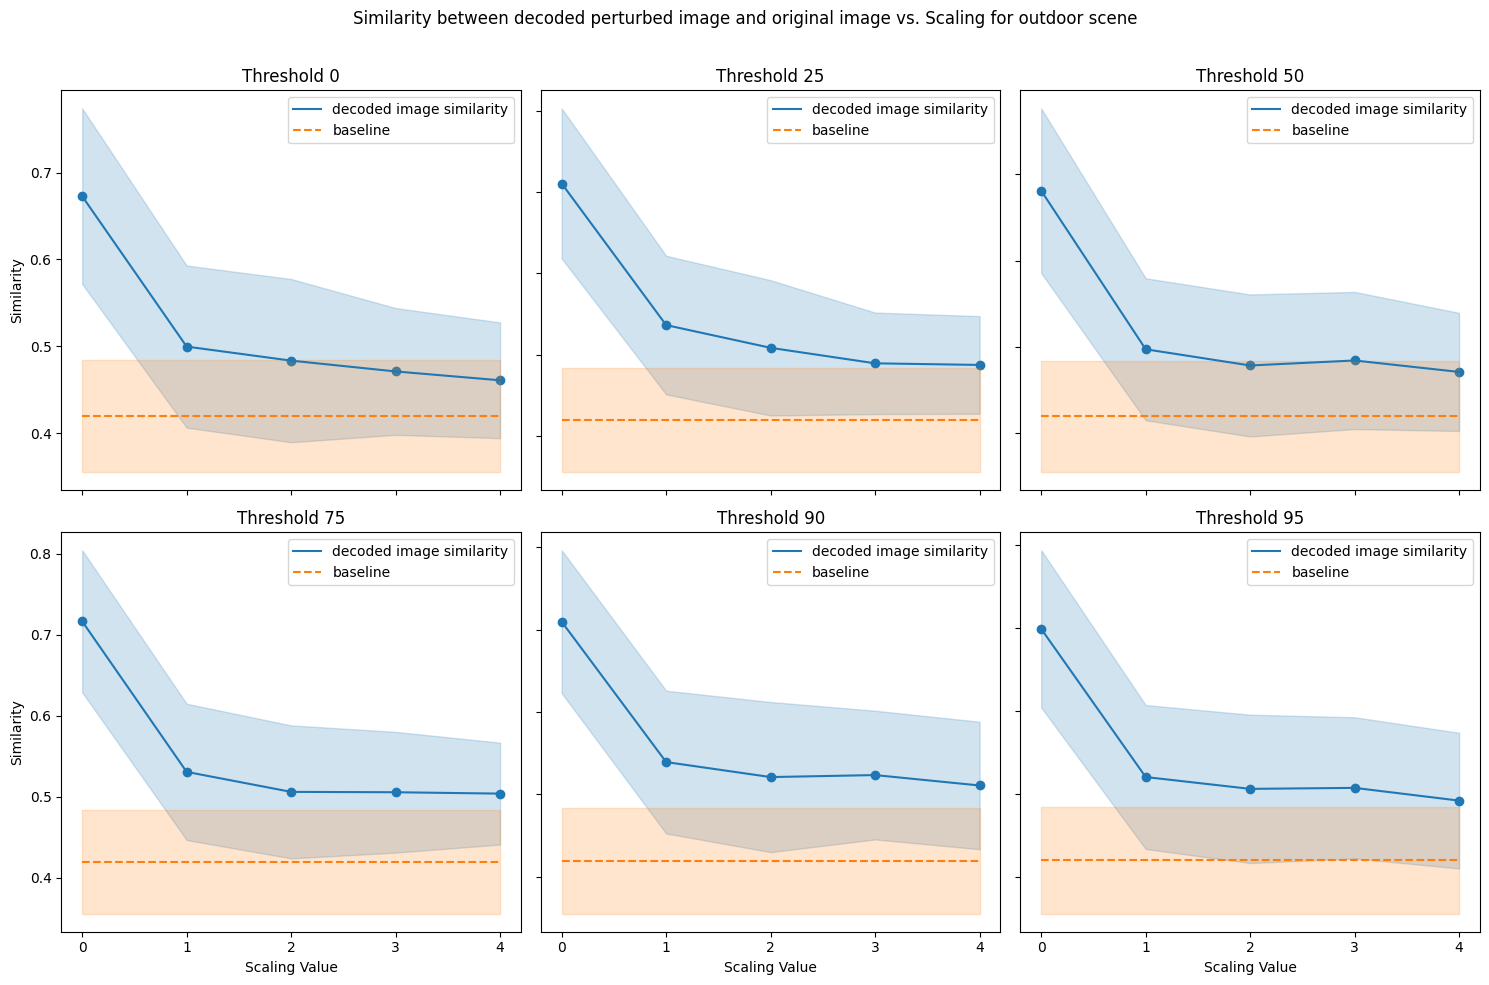

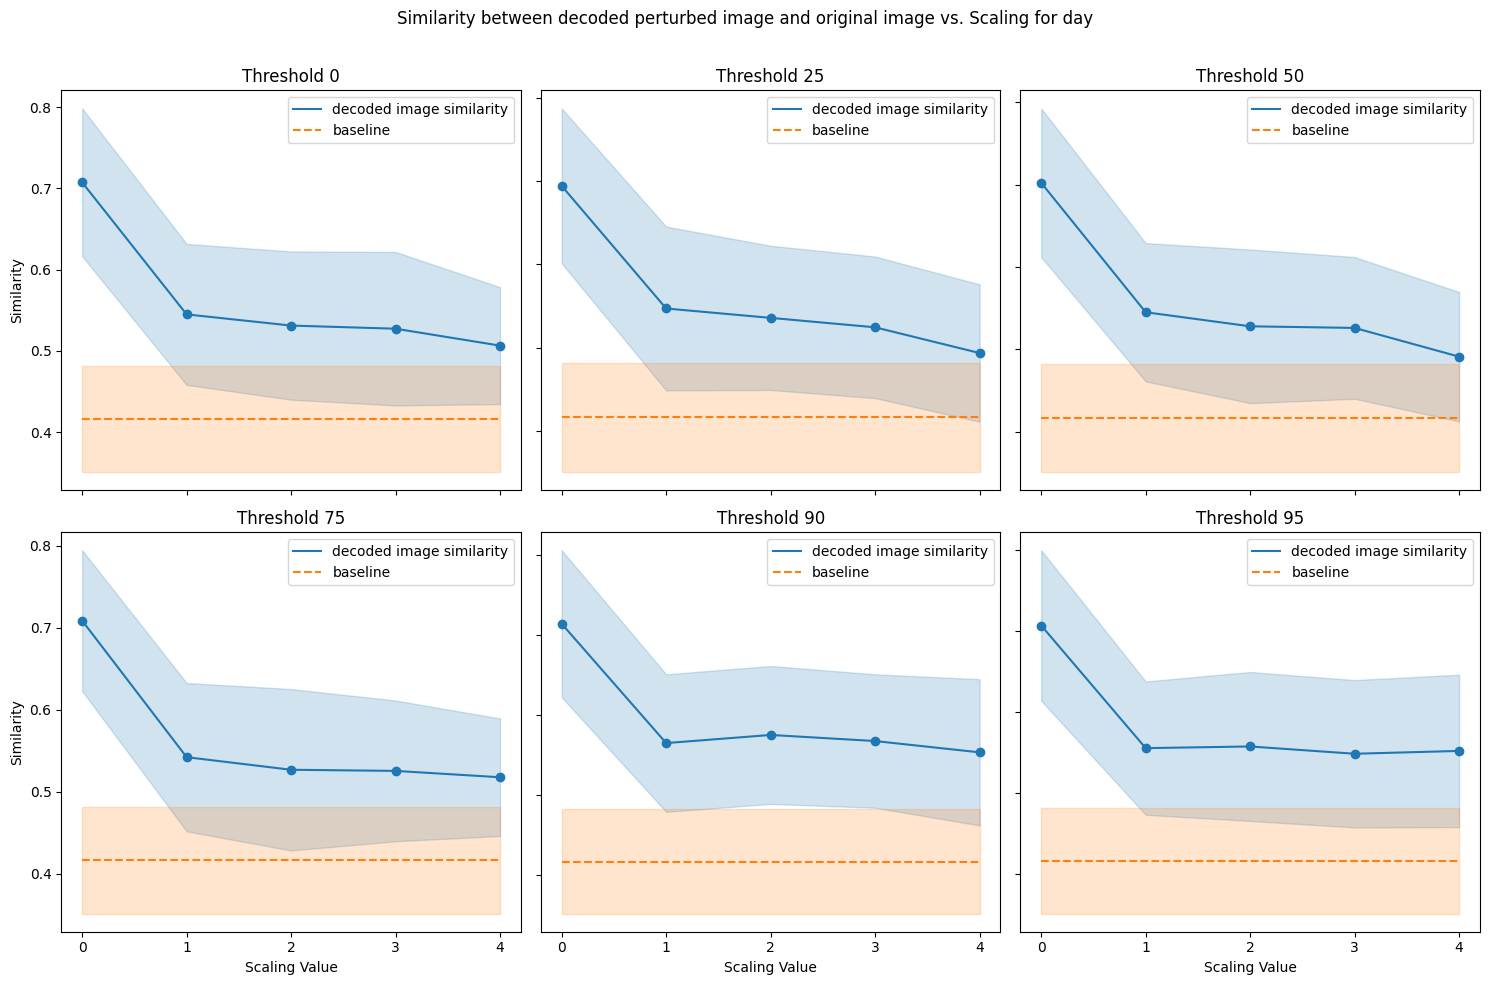

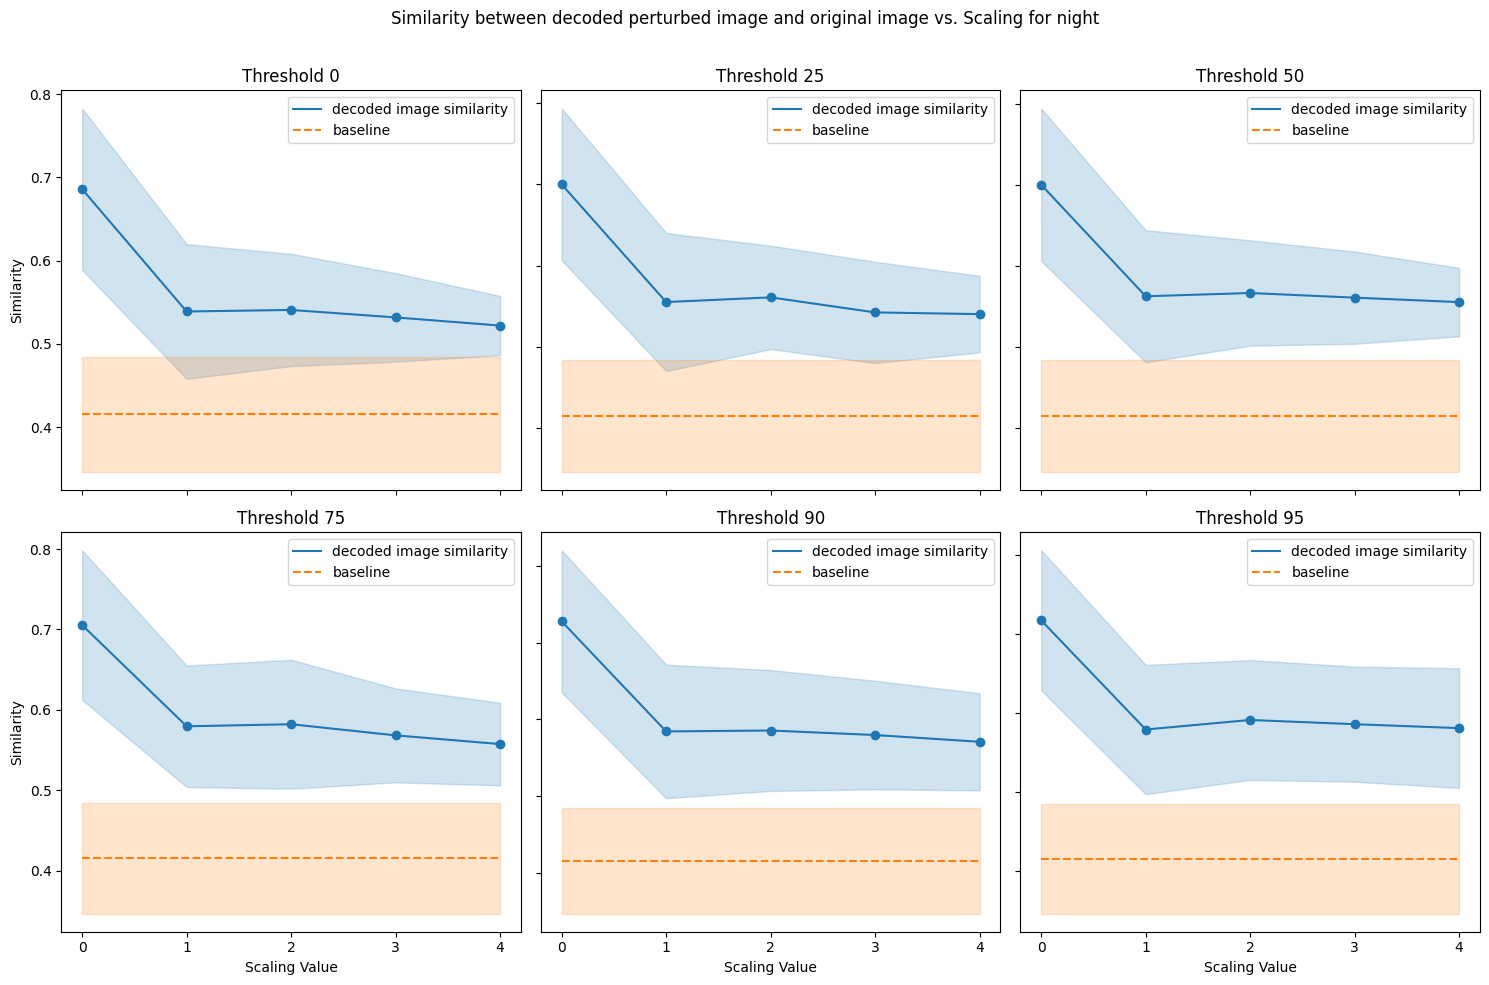

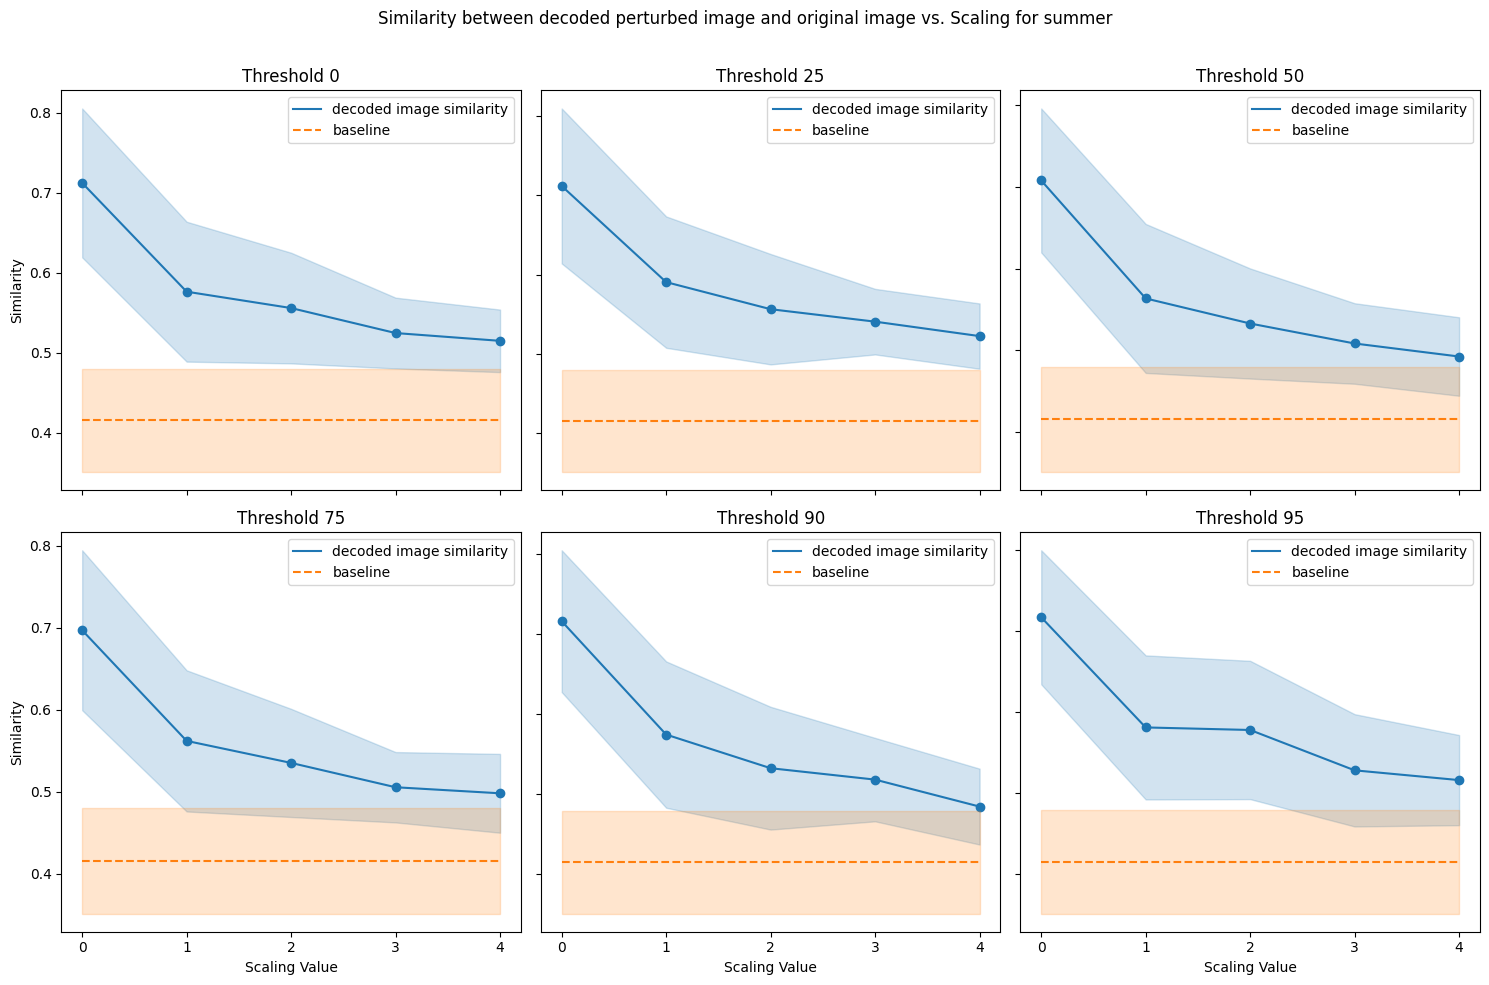

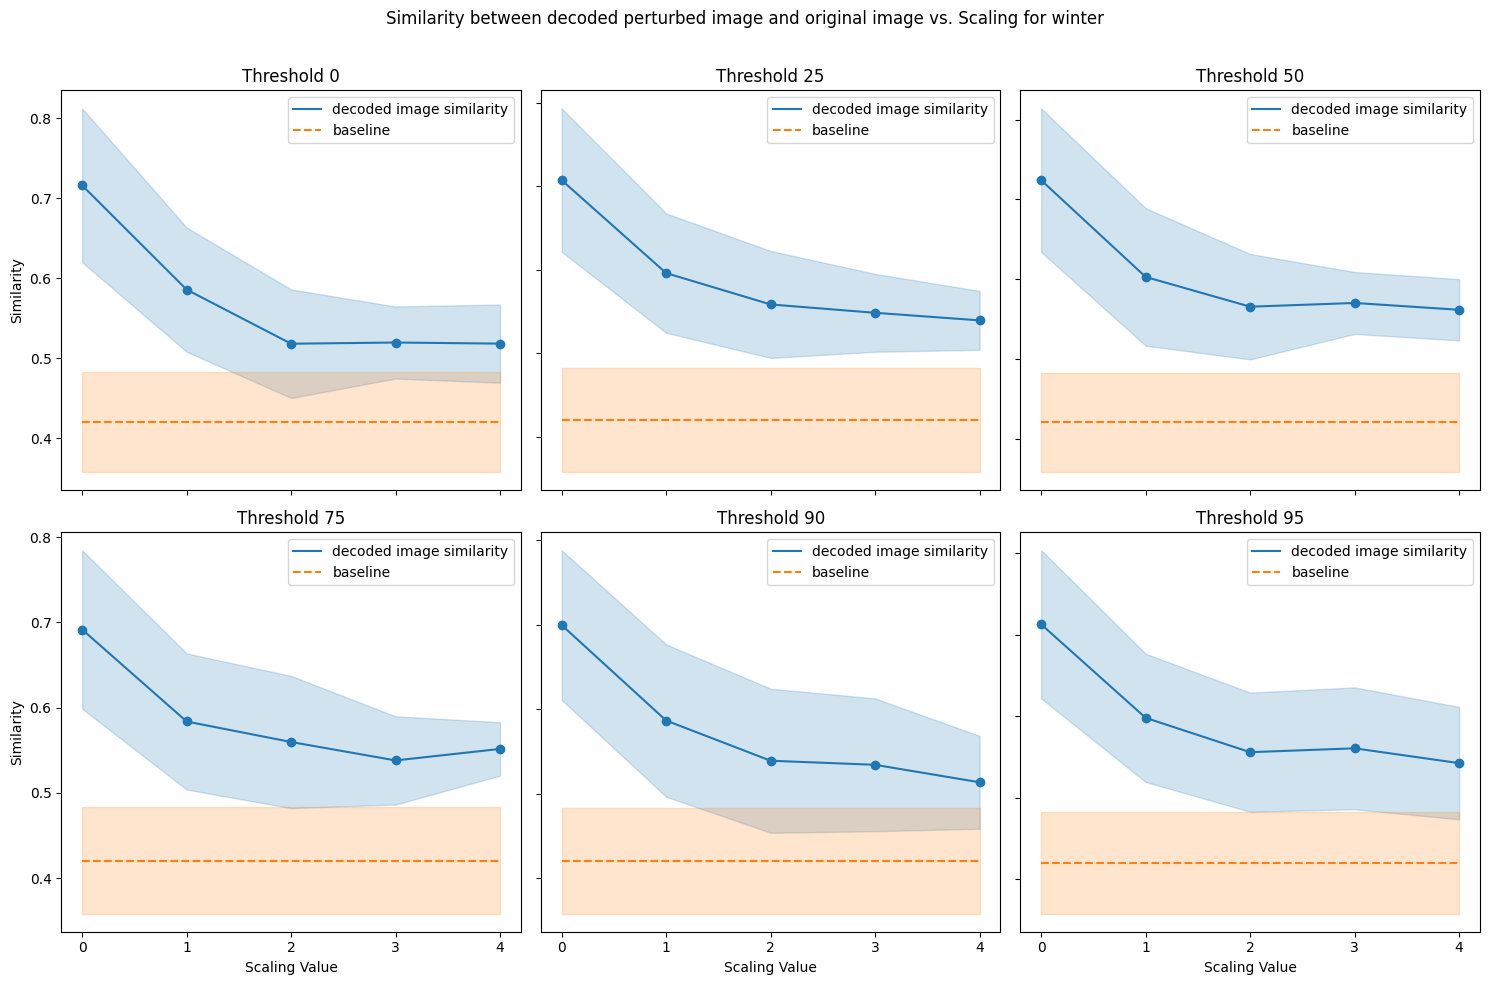

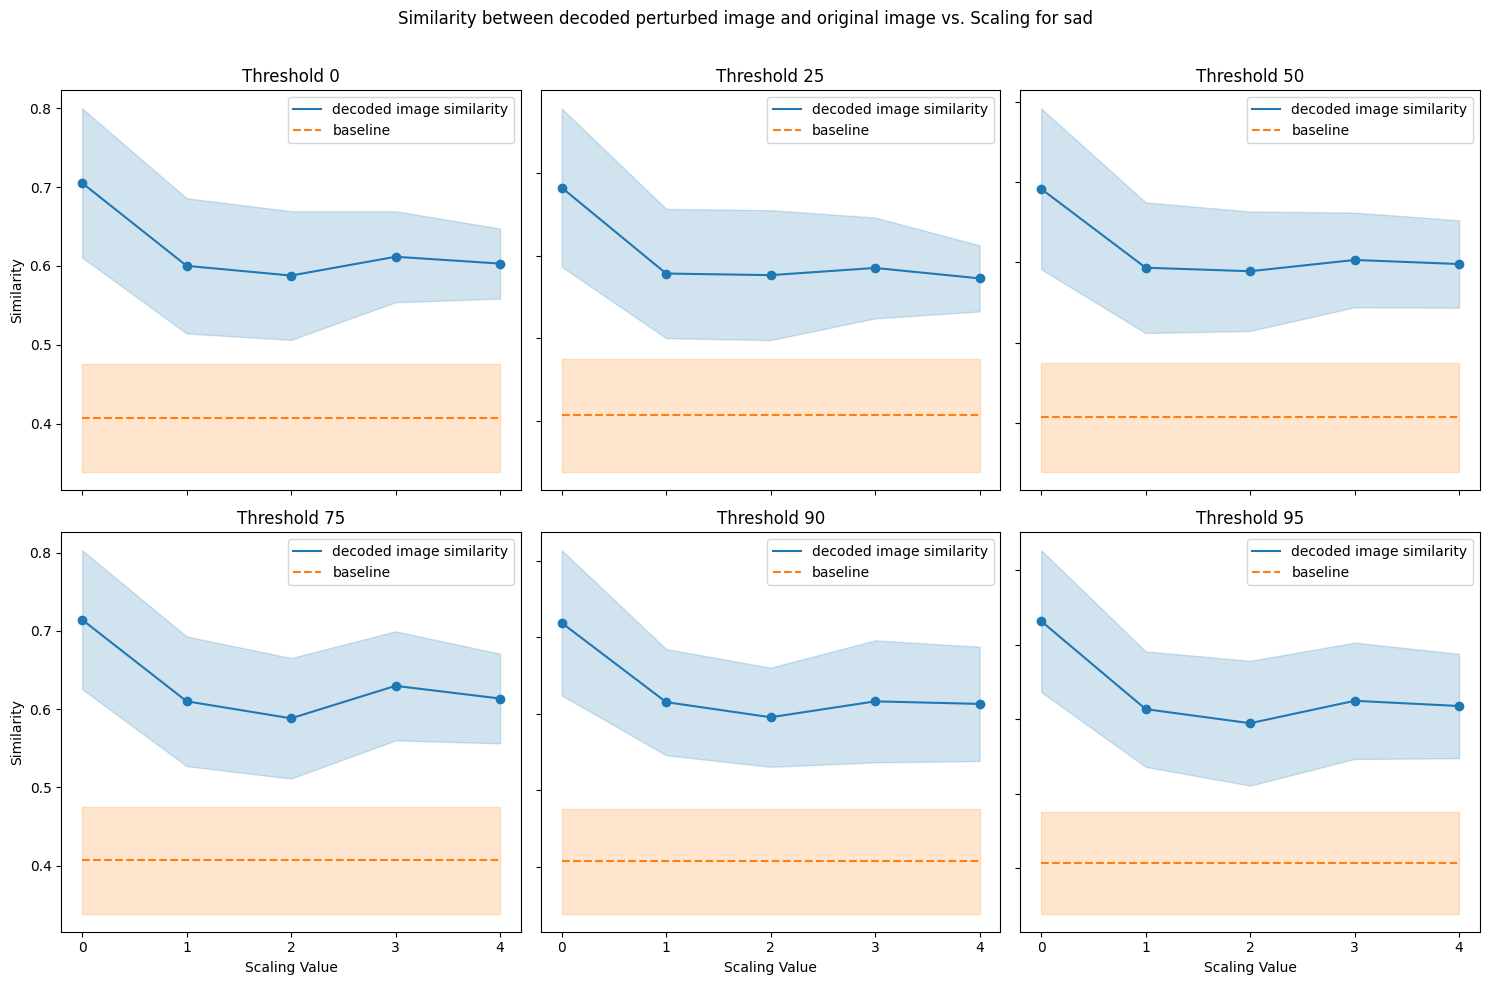

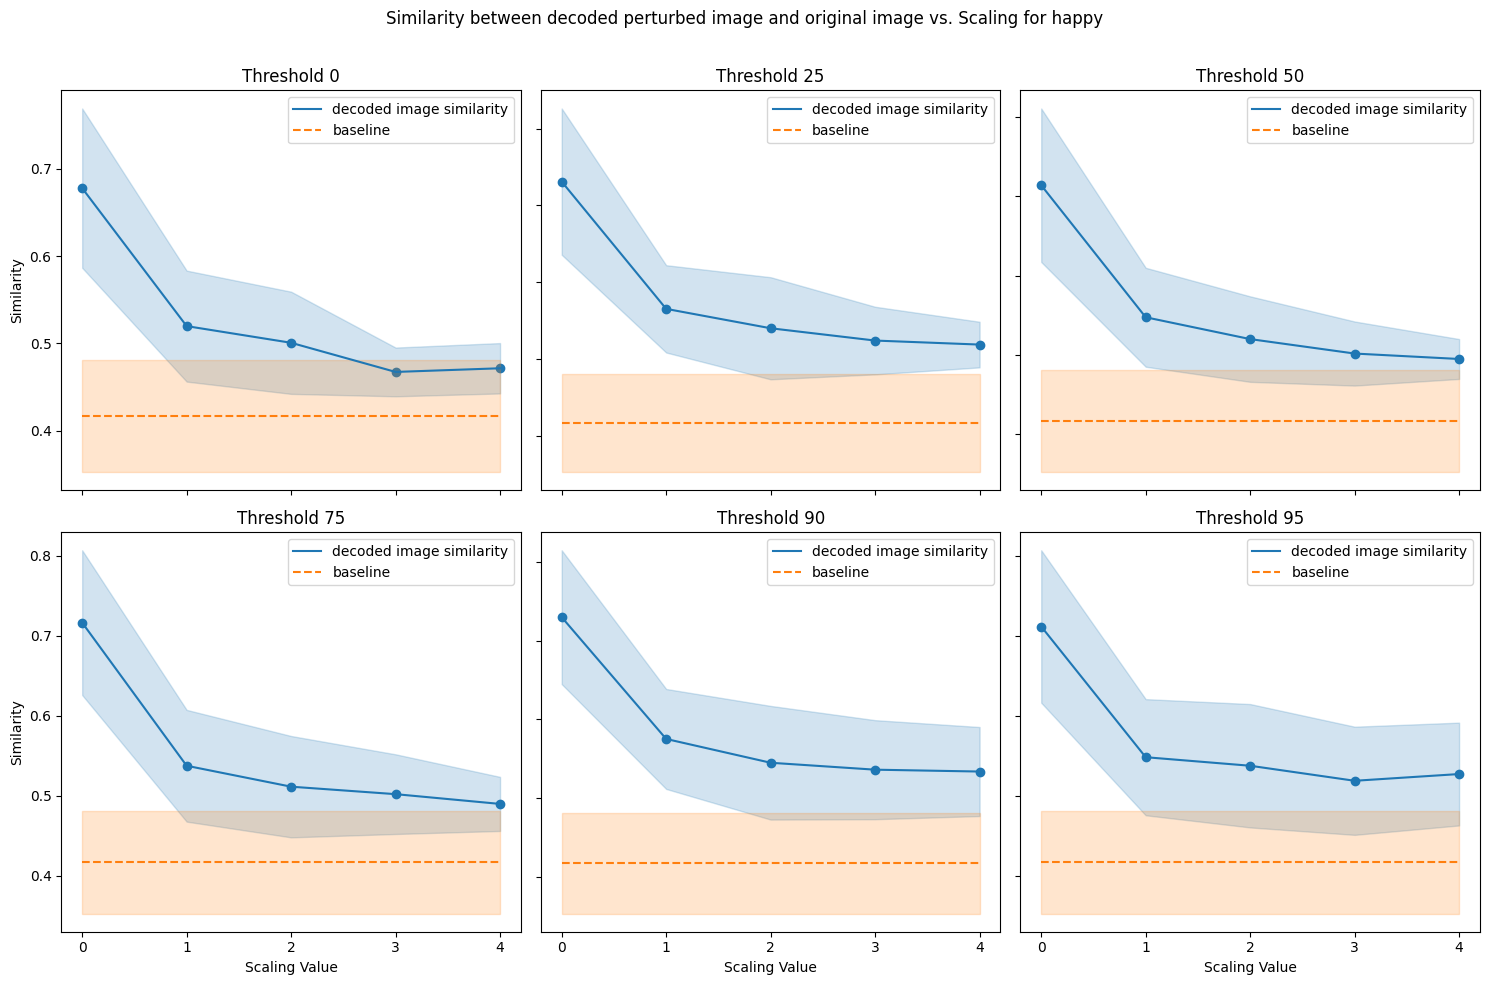

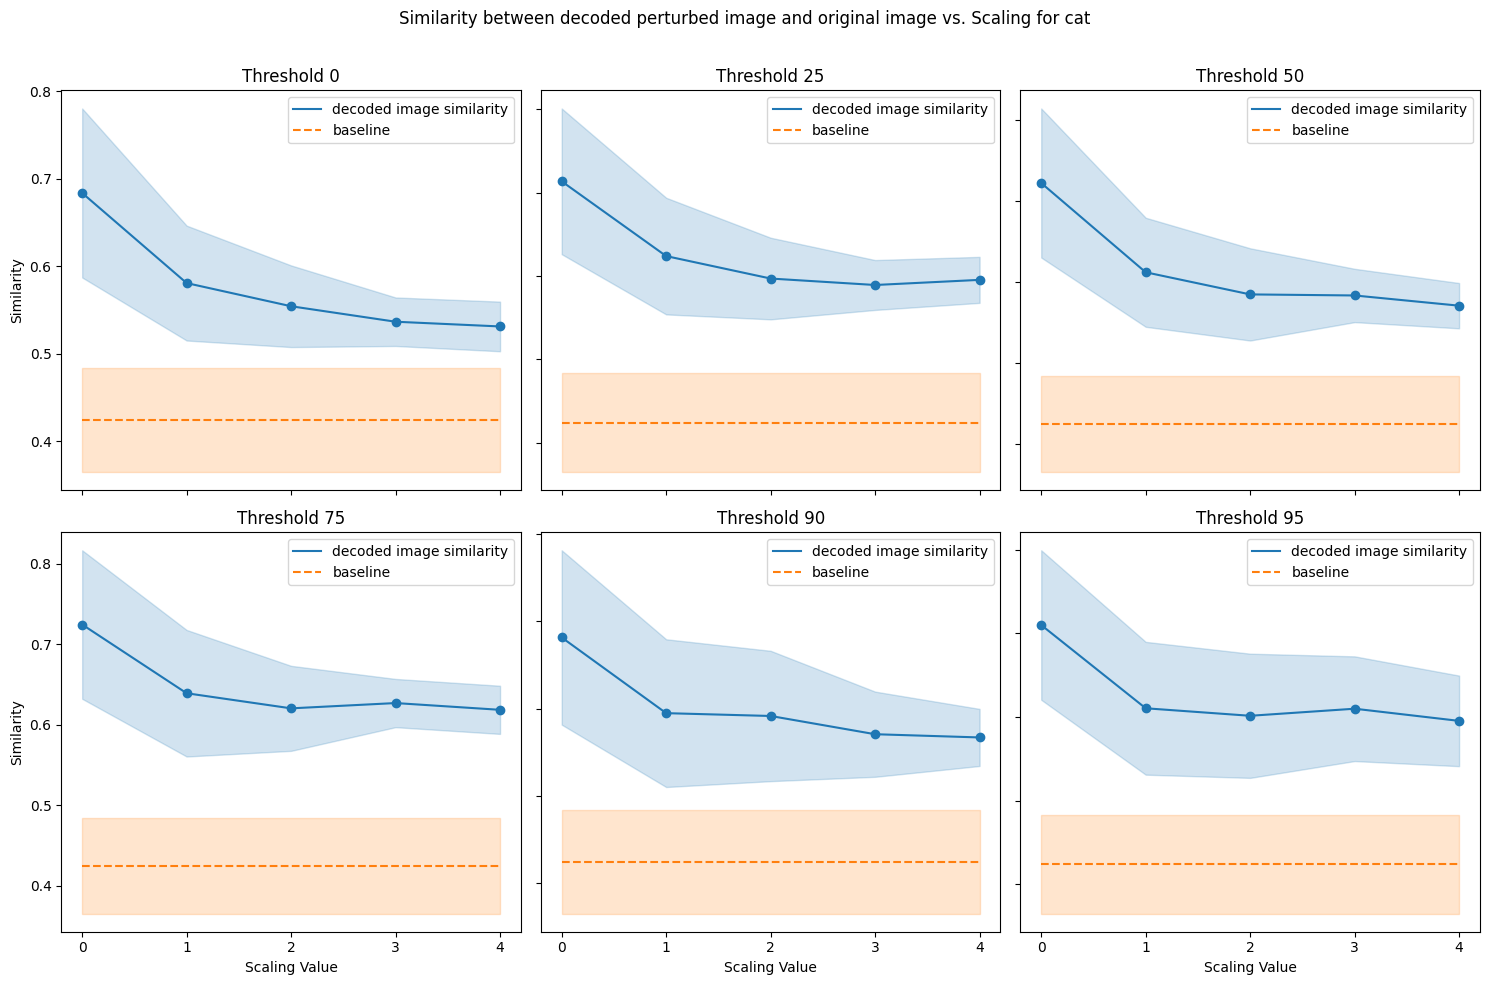

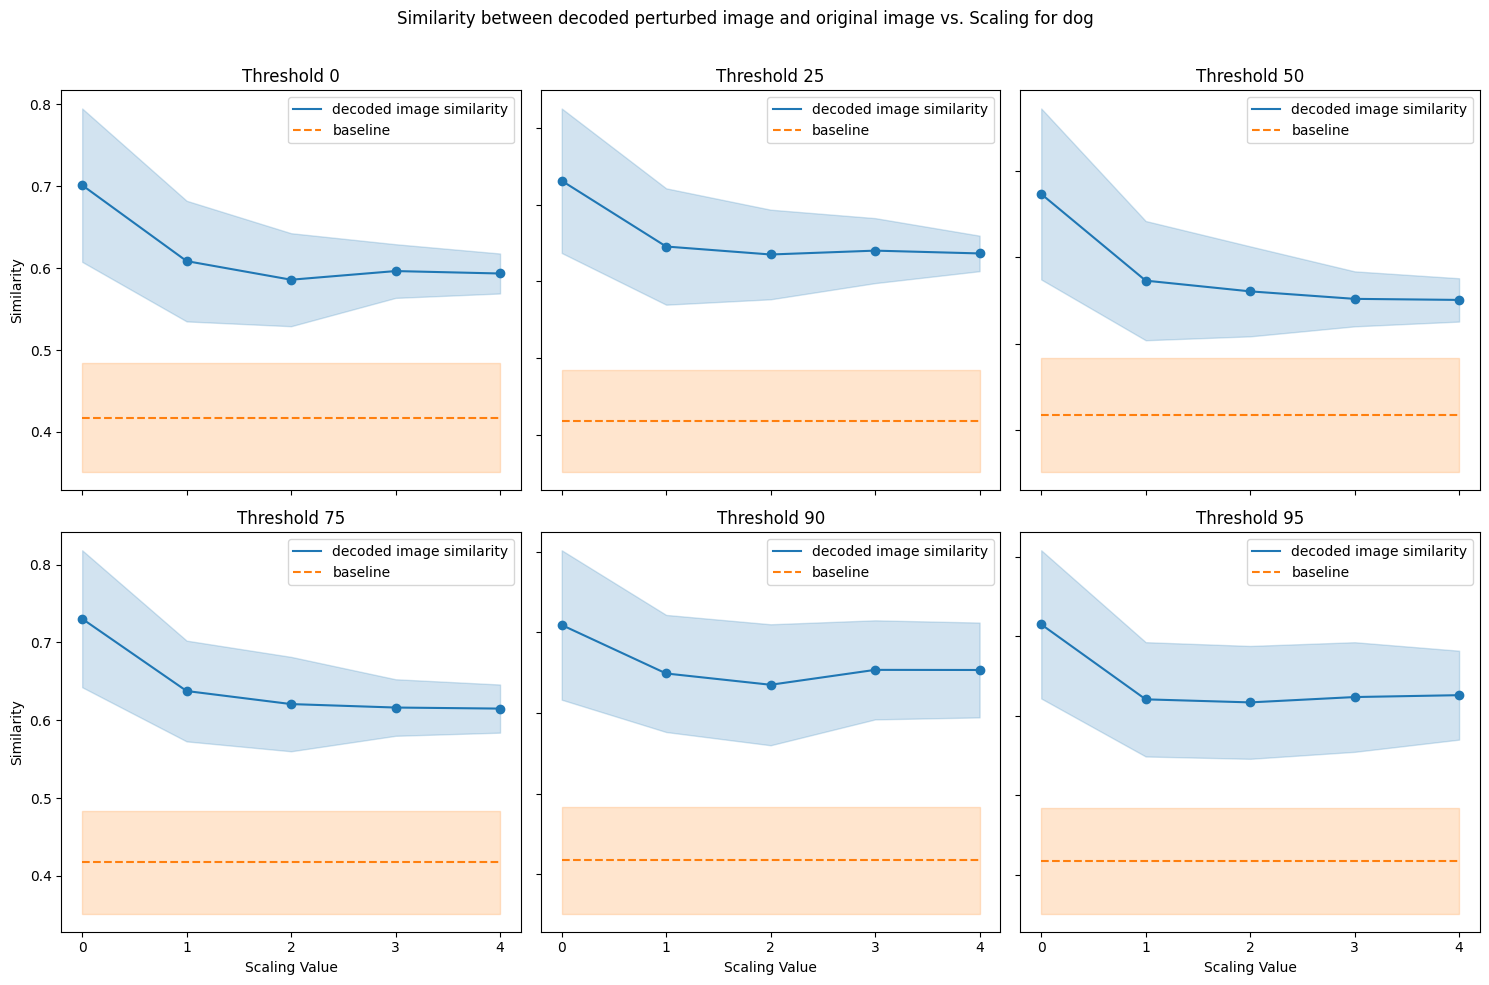

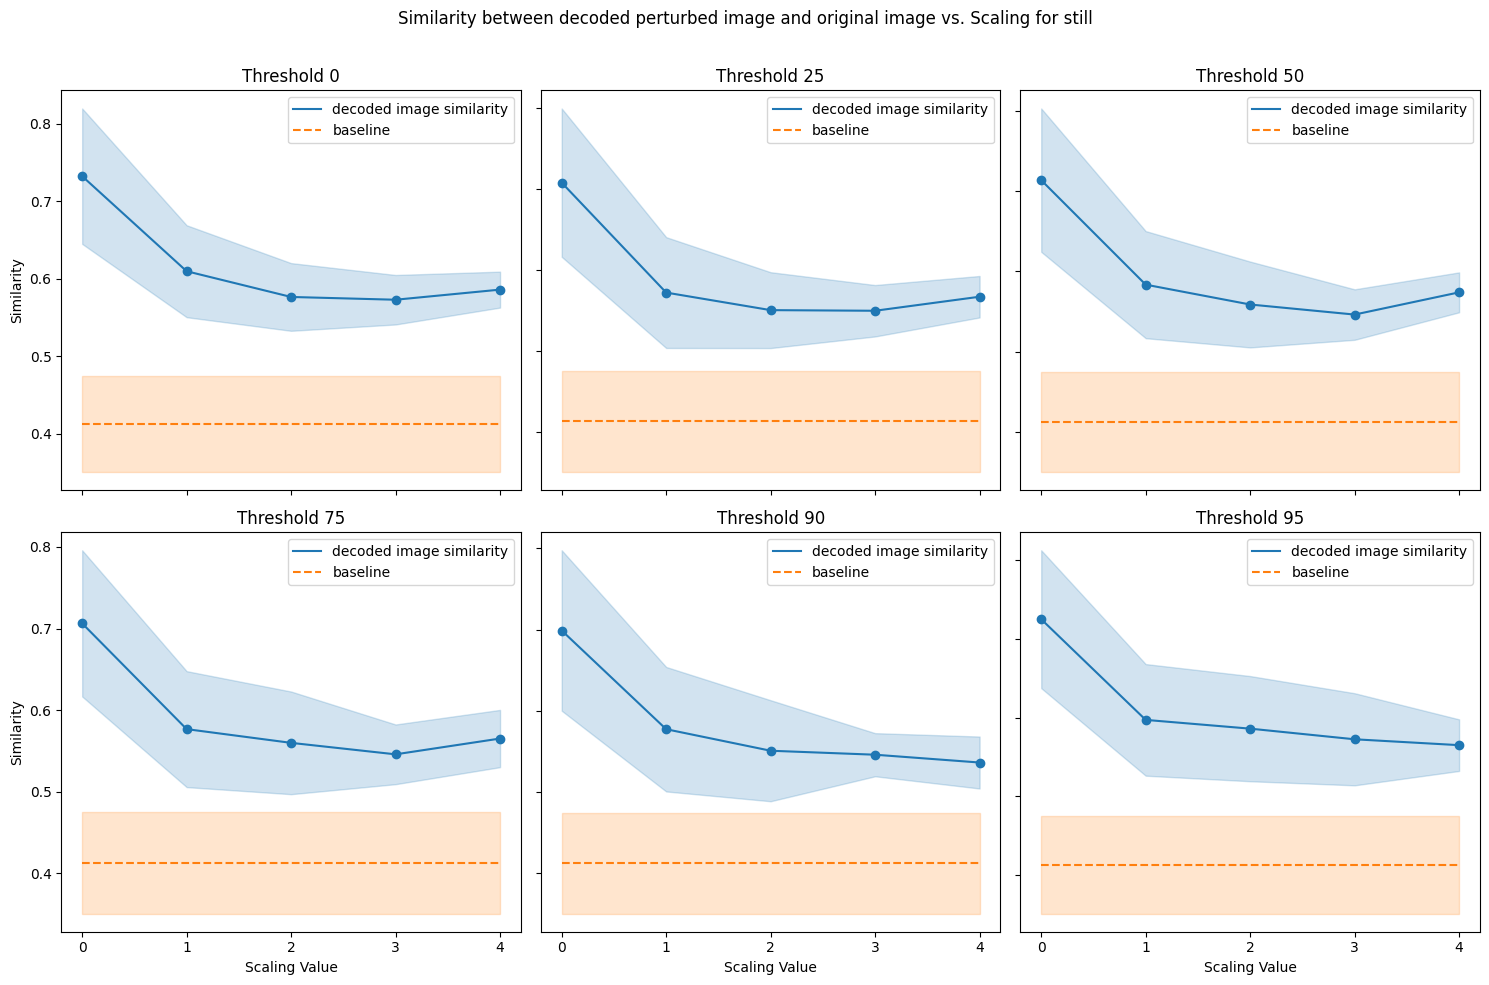

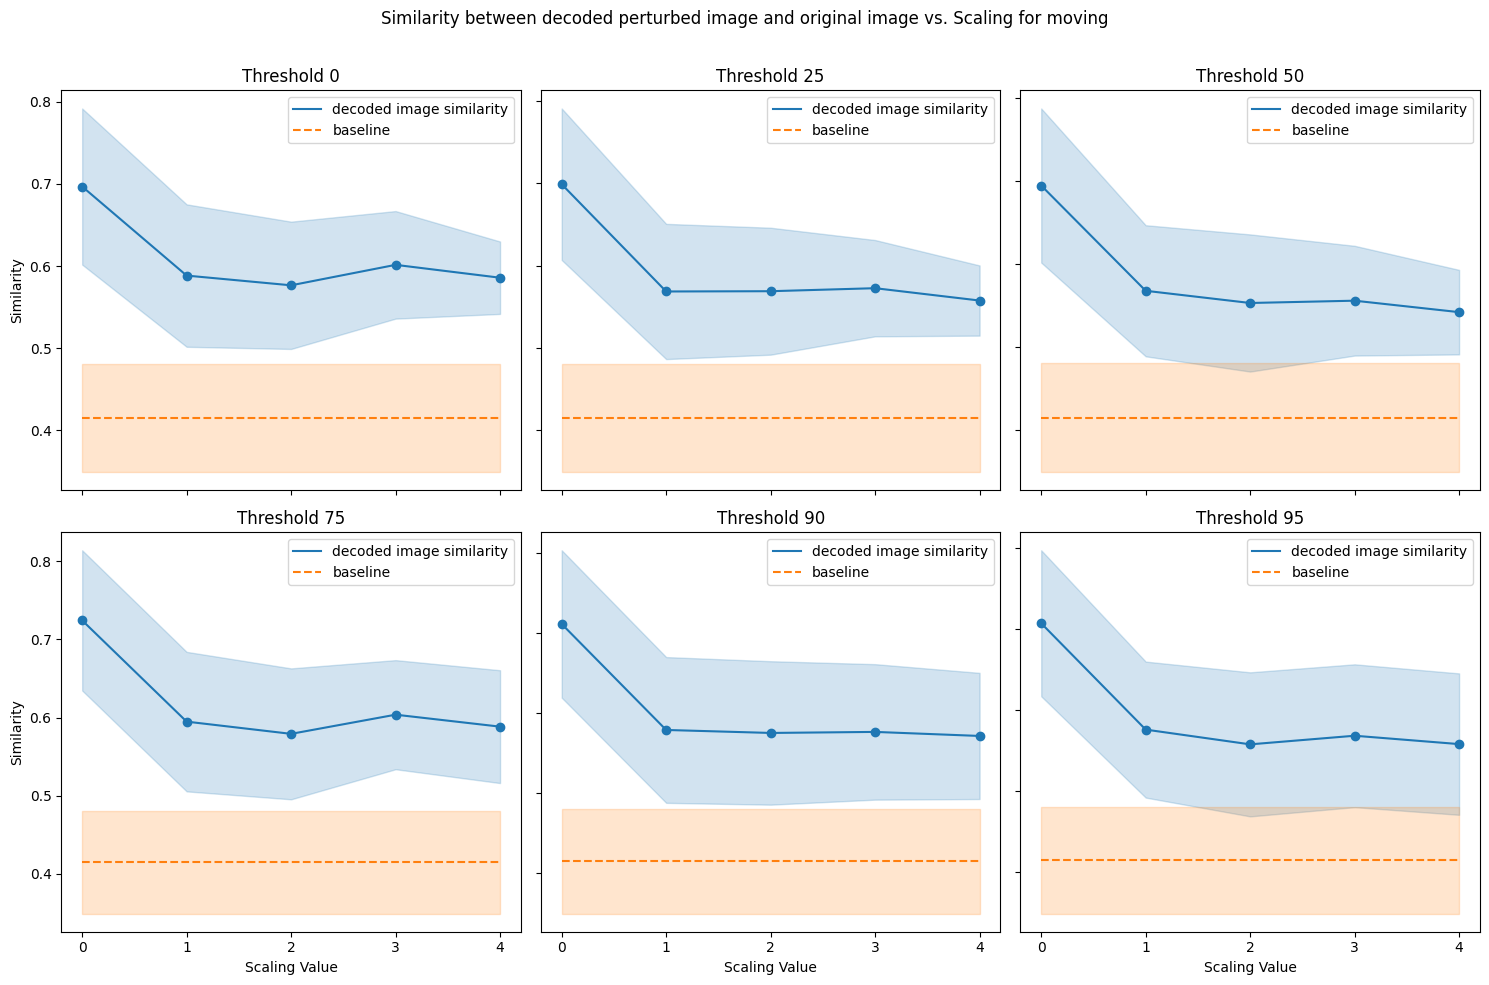

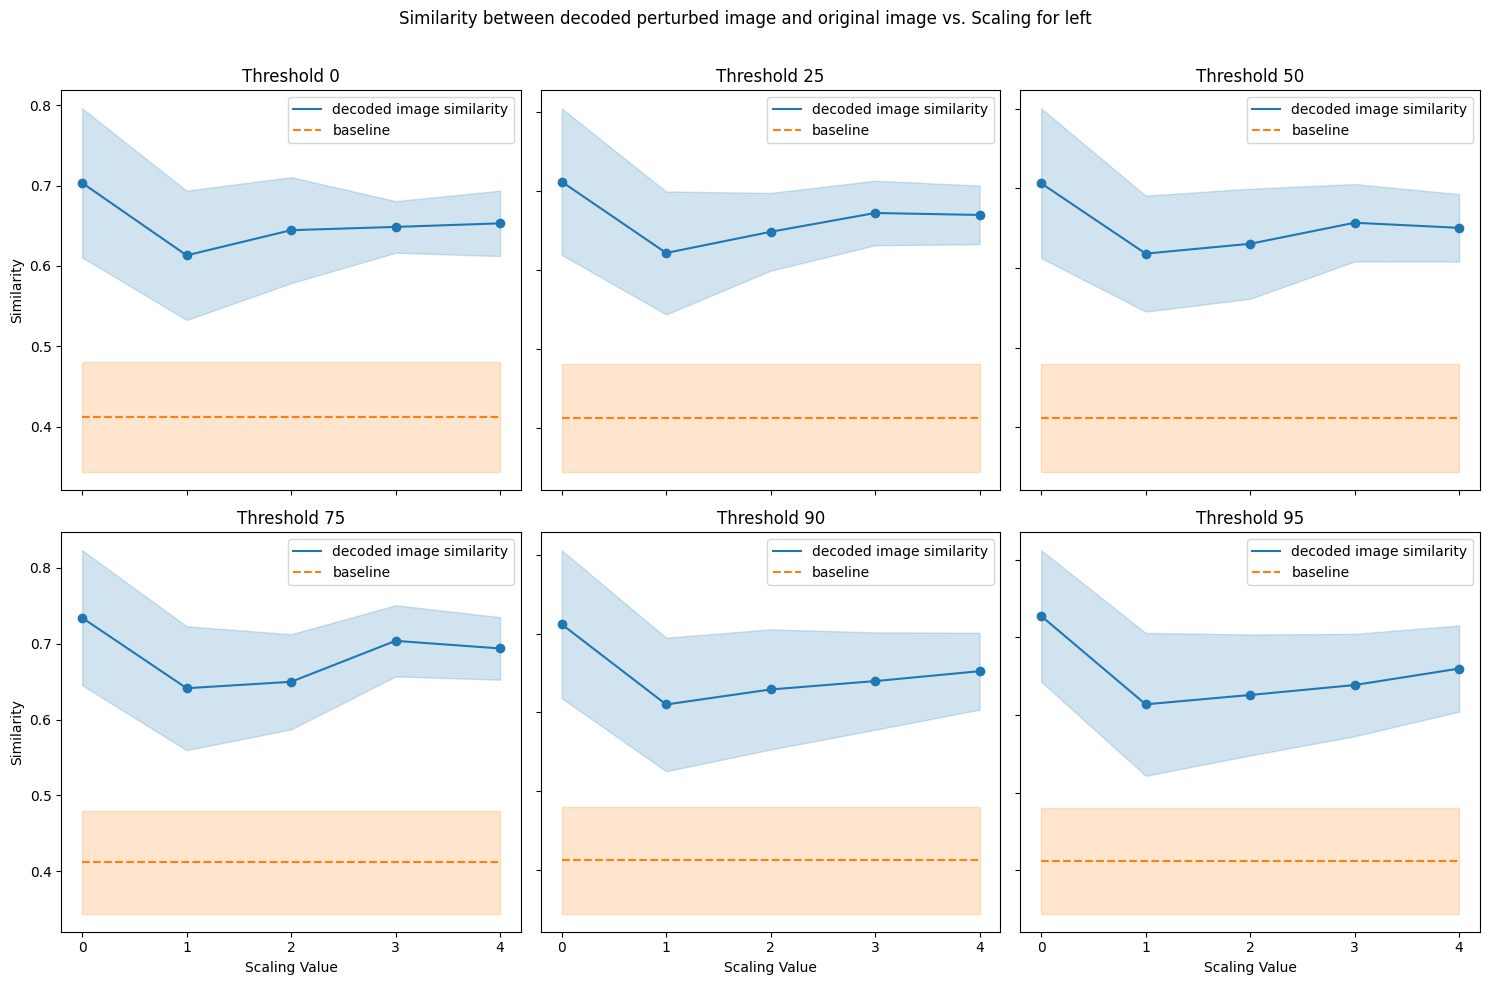

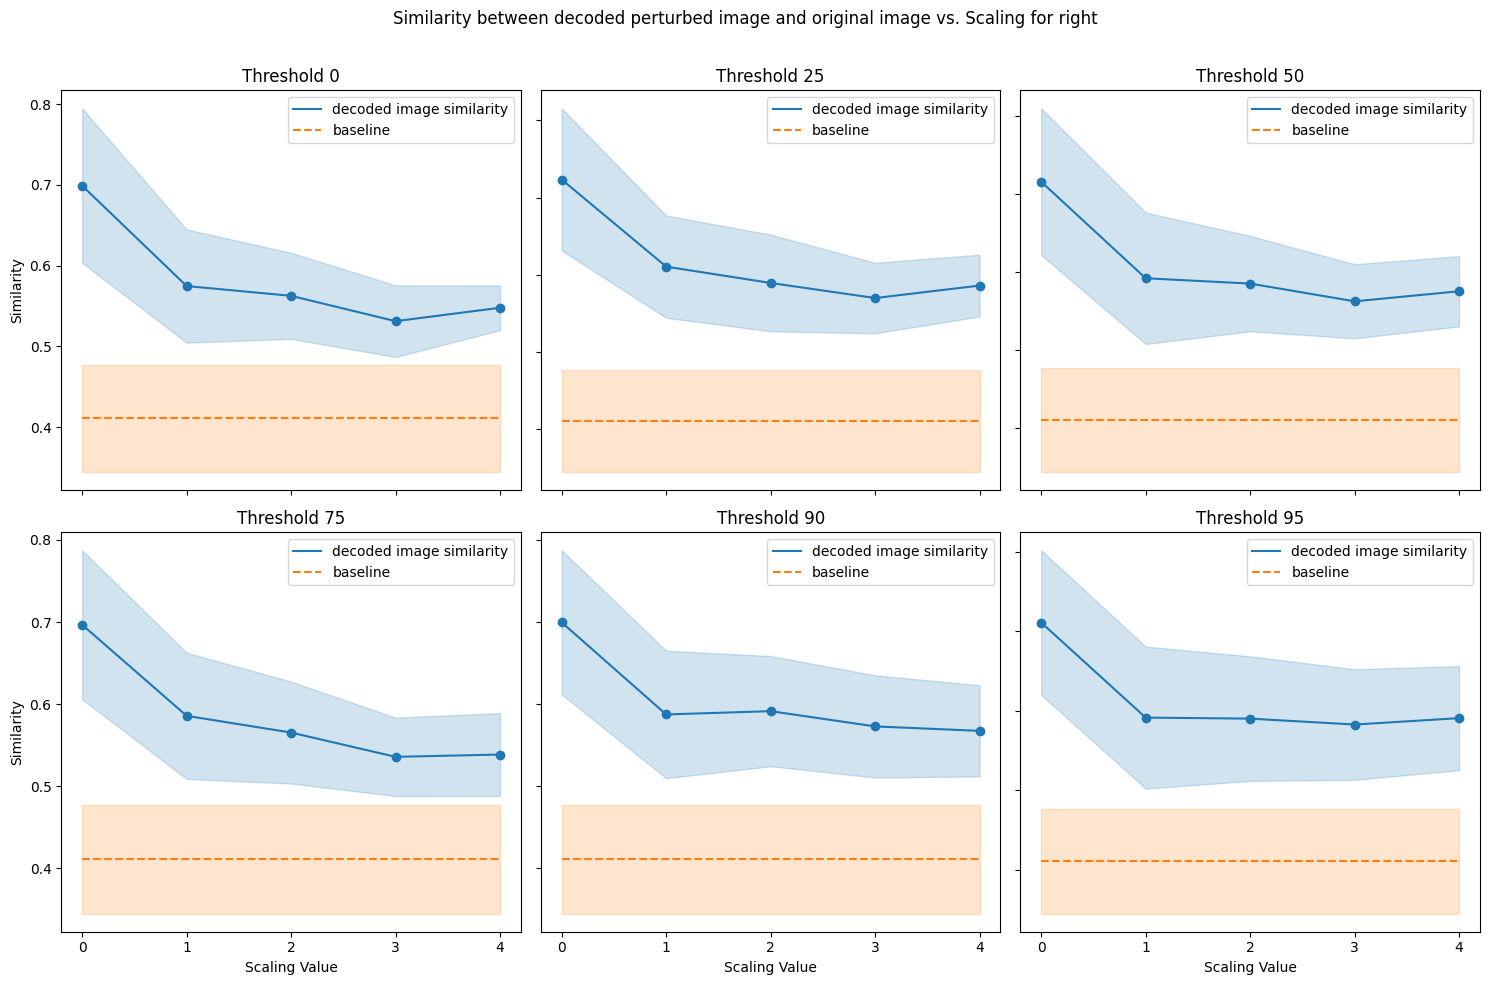

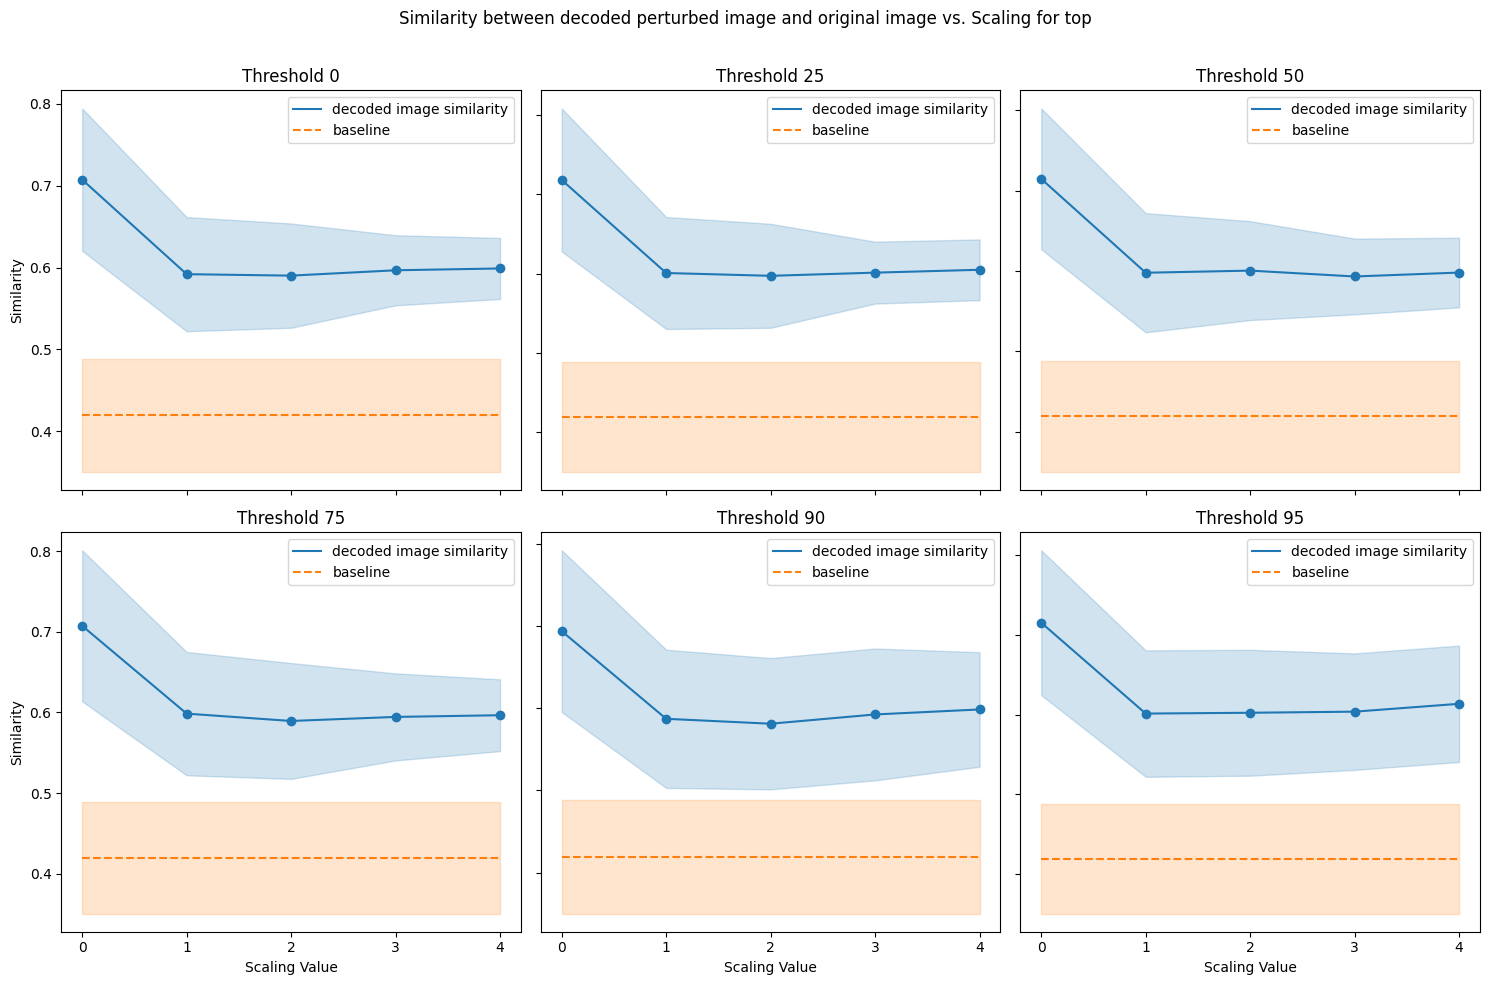

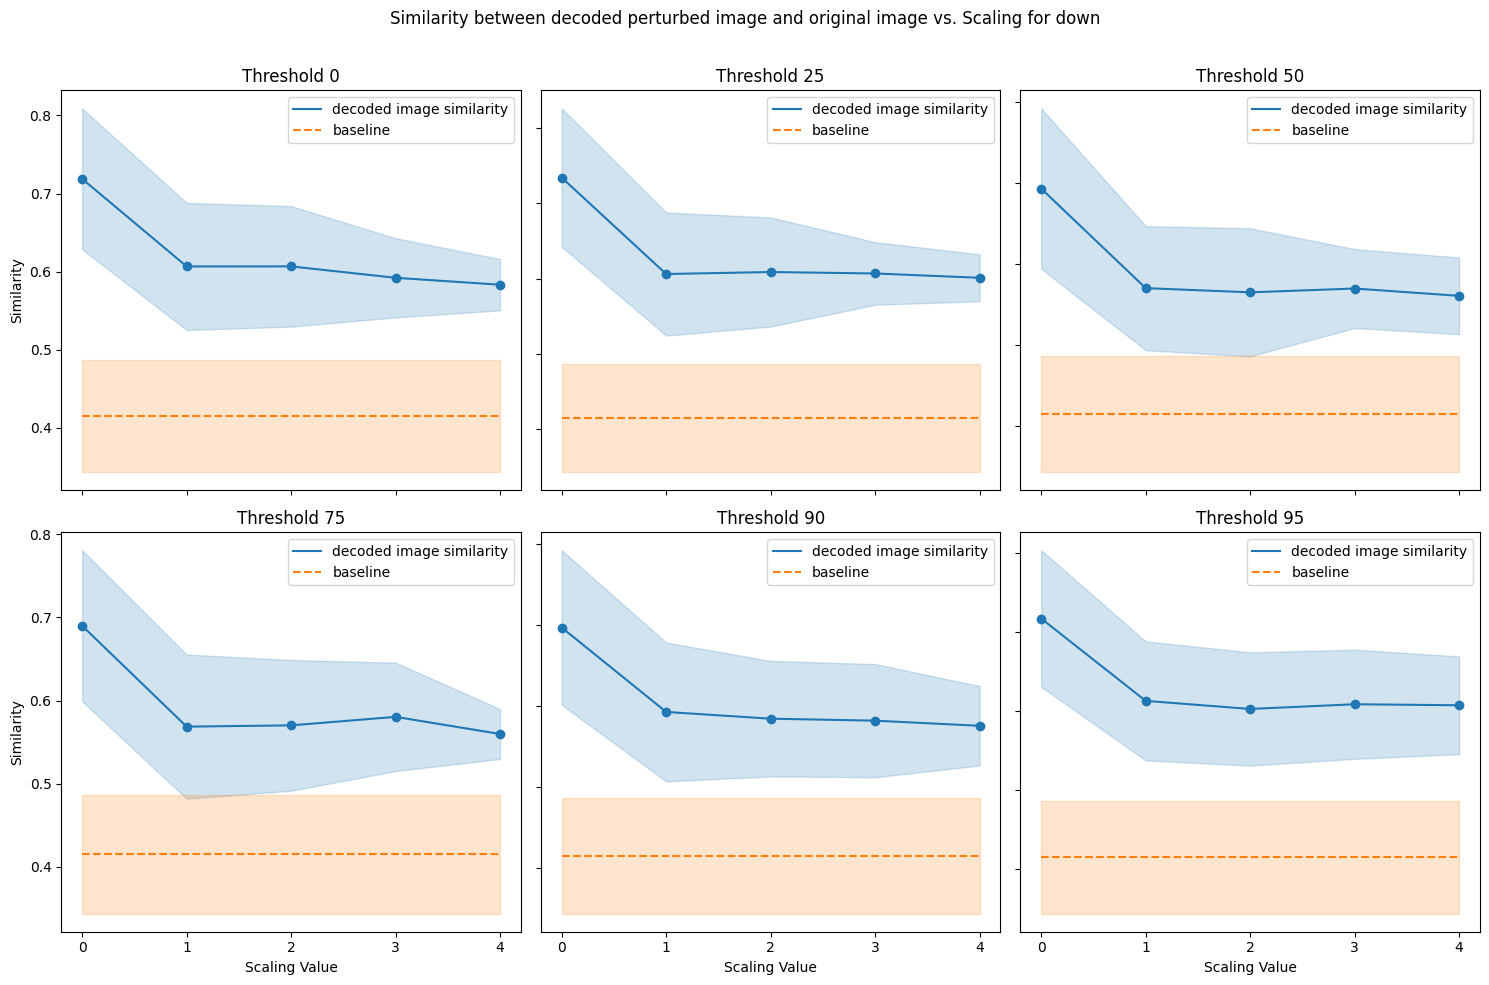

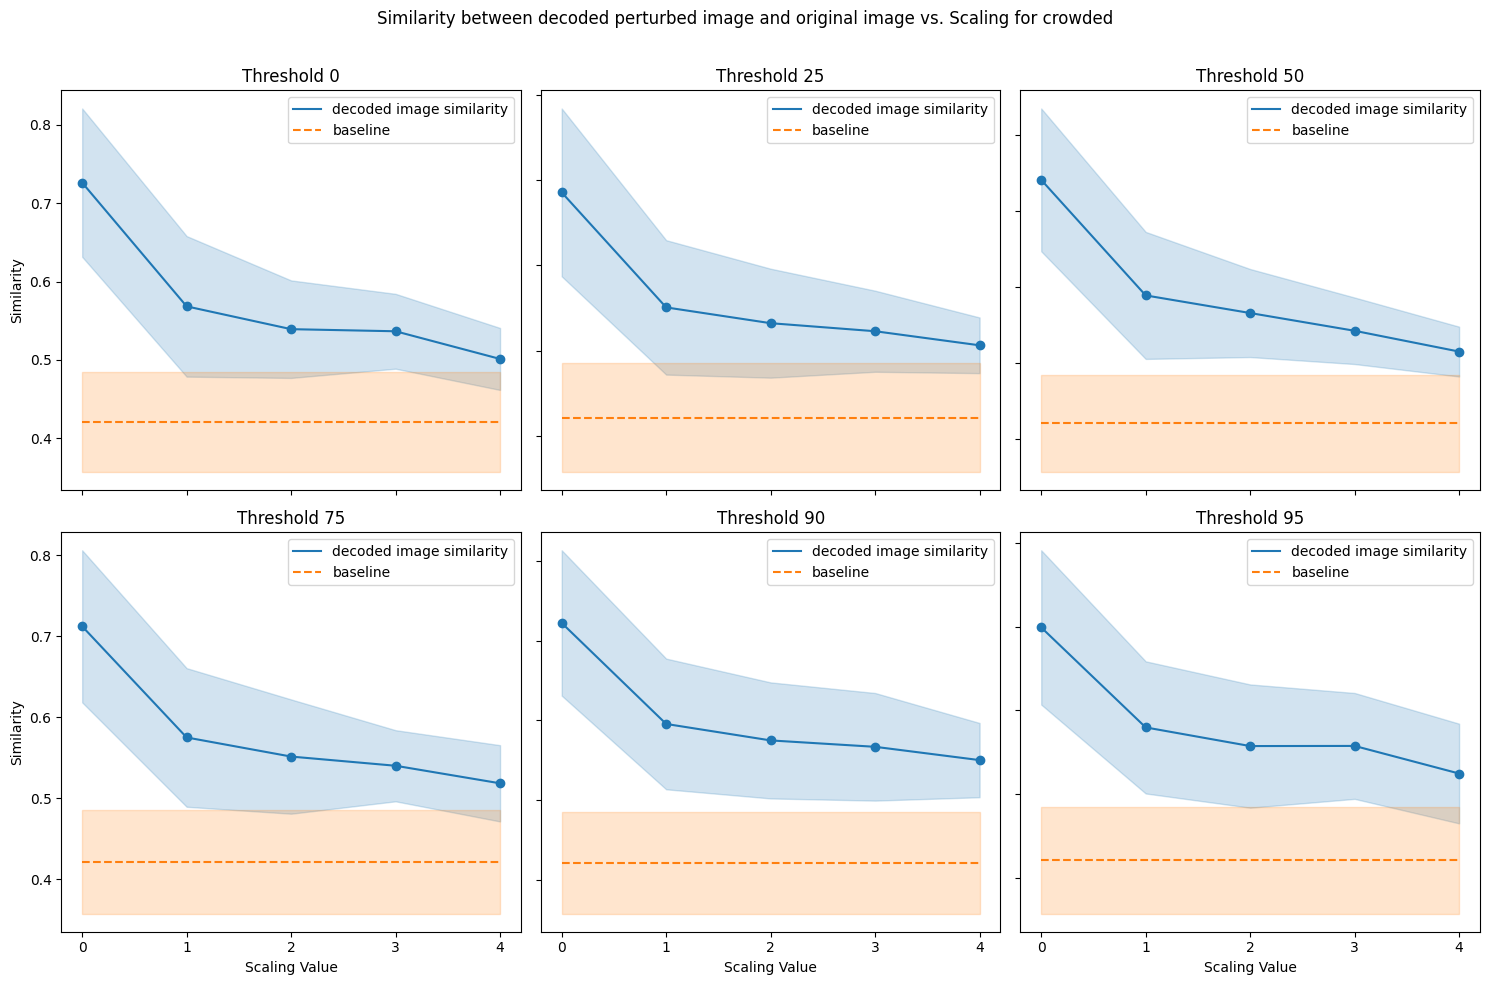

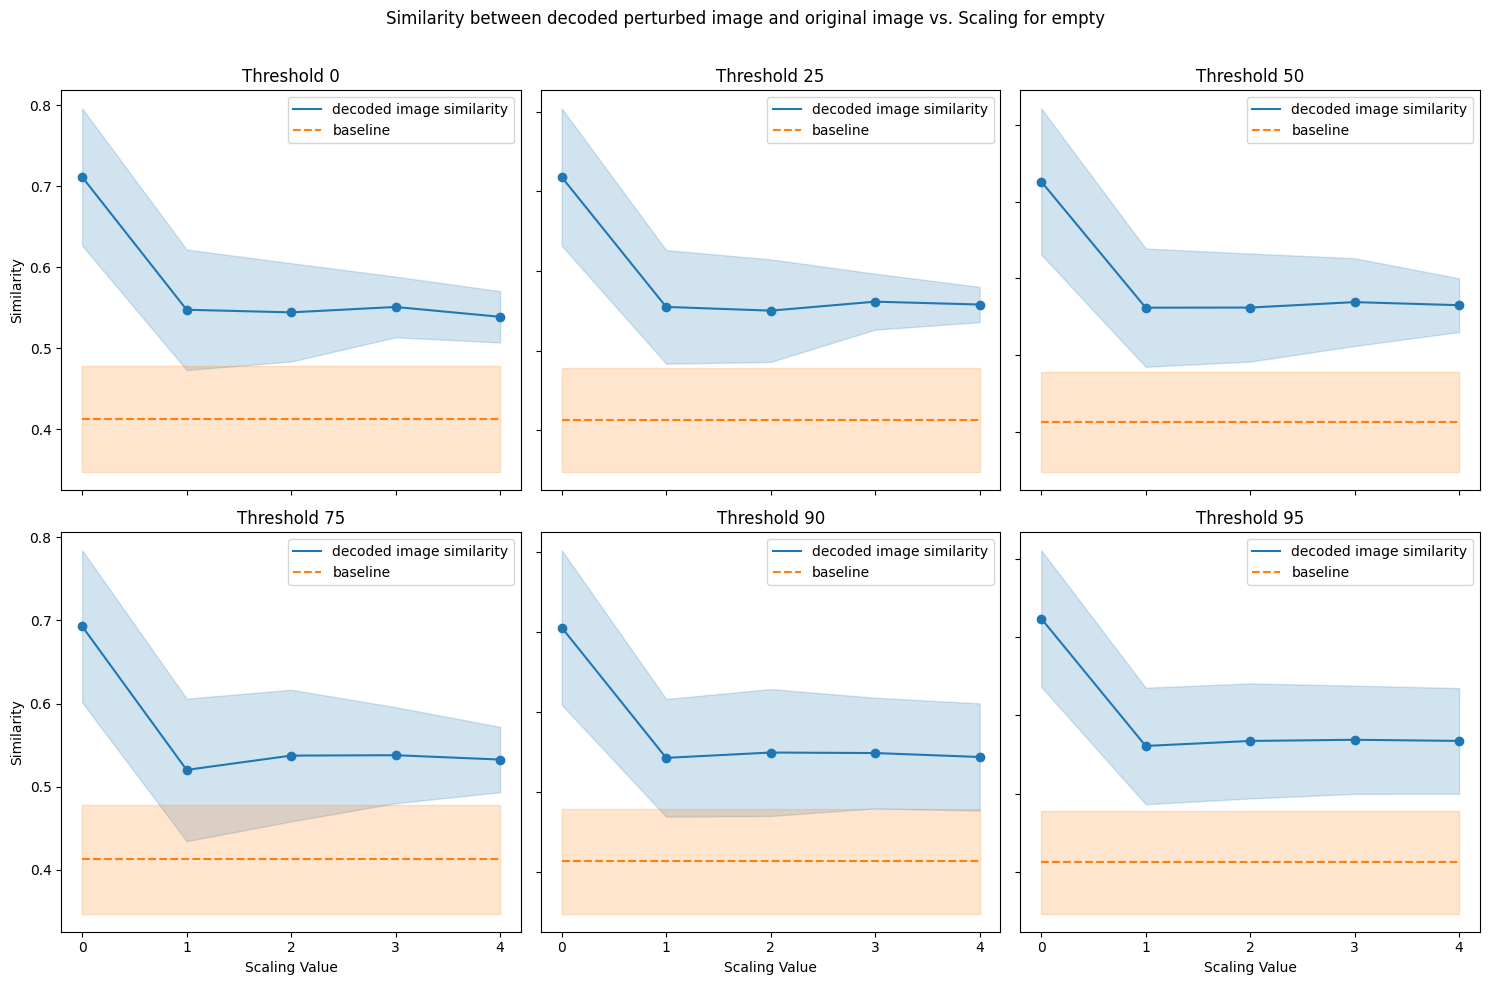

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj
from scipy.special import softmax


results_dir =f"results_single/{sub}"
os.makedirs(results_dir,exist_ok=True)

# Updated plotting results
# scaling_values = [-4,-3,-2,-1,0,1,2,3,4]  # Corresponding scaling values without "original"
scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]


# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

## INDICES 0: concept, 1: stimulus image

for pair in unrolled_concepts:
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}")

    for idx, thr in enumerate(thrs):
        row = idx // n_cols
        col = idx % n_cols

        y1_means = []
        y2_means = []
        y1_stds = []
        y2_stds = []

        for key in all_keys:
            img_embeds = all_results[thr][pair][key]  #similarity with concept!
            
            
            
            y1_means.append(img_embeds[:,0].mean())
            y2_means.append(img_embeds[:, 1].mean())
            y1_stds.append(img_embeds[:,0].std())
            y2_stds.append(img_embeds[:, 1].std())
            
        
        y1_means = np.array(y1_means)
        y2_means = np.array(y2_means)
        y1_stds = np.array(y1_stds)
        y2_stds = np.array(y2_stds)
        
            
        ##baseline correction
        # y1_means = y1_means - baselines[pair]["baseline_concept_similarities"].numpy()
        # y2_means = y2_means - baselines[pair]["baseline_img_similarities"].mean().numpy()
        # y1_means = softmax(y1_means)
        # y1_stds = softmax(y1_stds)
        
#         soft_values = softmax(np.stack([y1_means,y2_means],1),1)
#         y1_means = soft_values[:,0]
#         y2_means = soft_values[:,1]
        

        # Plot mean and fill area for standard deviation
        # axs[row, col].plot(scaling_values, y1_means, label=f"{pair} similarity")
        # axs[row, col].fill_between(scaling_values, 
        #                            np.array(y1_means) - np.array(y1_stds), 
        #                            np.array(y1_means) + np.array(y1_stds), alpha=0.2)
        
        # axs[row,col].hlines(baselines[pair]["baseline_concept_similarities"],xmin=0,xmax=4)

        axs[row, col].plot(scaling_values, y2_means, label=f"decoded image similarity")
        axs[row, col].scatter(scaling_values, y2_means)
        axs[row, col].fill_between(scaling_values, 
                                   np.array(y2_means) - np.array(y2_stds), 
                                   np.array(y2_means) + np.array(y2_stds), alpha=0.2,color="tab:blue")
        axs[row,col].set_xticks(scaling_values)
        
        axs[row,col].hlines(baselines[pair]["baseline_img_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:orange",label="baseline")
        axs[row, col].fill_between(x=scaling_values, y1=baselines[pair]["baseline_img_similarities_mean"].mean()-baselines[pair]["baseline_img_similarities_std"].mean(), 
                                   y2=baselines[pair]["baseline_img_similarities_mean"].mean()+baselines[pair]["baseline_img_similarities_std"].mean(),color="tab:orange",alpha=0.2)

        axs[row, col].set_ylabel("Similarity")
        axs[row, col].set_title(f"Threshold {thr}")
        axs[row, col].legend()

        # Add arrows to indicate concept directions
        center = 0  # Index of 0 on the x-axis
#         axs[row, col].annotate("", xy=(4, 0.5), xytext=(0, 0.5),
#                                arrowprops=dict(arrowstyle="->",facecolor='black'),
#                                horizontalalignment='center', verticalalignment='center',
#                                fontsize=12, color='black')
#         axs[row, col].annotate(f"more {pair}",xy = (2,0.45),  xytext=(2, 0.45),
#                            horizontalalignment='center', verticalalignment='center',
#                            fontsize=12, color='black')
        
#         axs[row, col].annotate(f"", xy=(0, 0.5), xytext=(-4, 0.5),
#                                arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                                horizontalalignment='center', verticalalignment='center',
#                                fontsize=12, color='black')
#         axs[row, col].annotate(f"less {pair}", xy=(-2, 0.45), xytext=(-2, 0.45),
#                        arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                        horizontalalignment='center', verticalalignment='center',
#                        fontsize=12, color='black')

    # Set common x-axis label
    for ax in axs.flat:
        ax.label_outer()  # Hide inner labels to avoid clutter

    axs[-1, 0].set_xlabel("Scaling Value")
    axs[-1, 1].set_xlabel("Scaling Value")
    axs[-1, 2].set_xlabel("Scaling Value")
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
    plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and original image vs. Scaling for {pair}.png"))
    plt.show()
    
    


In [18]:
print(sub)

subj07


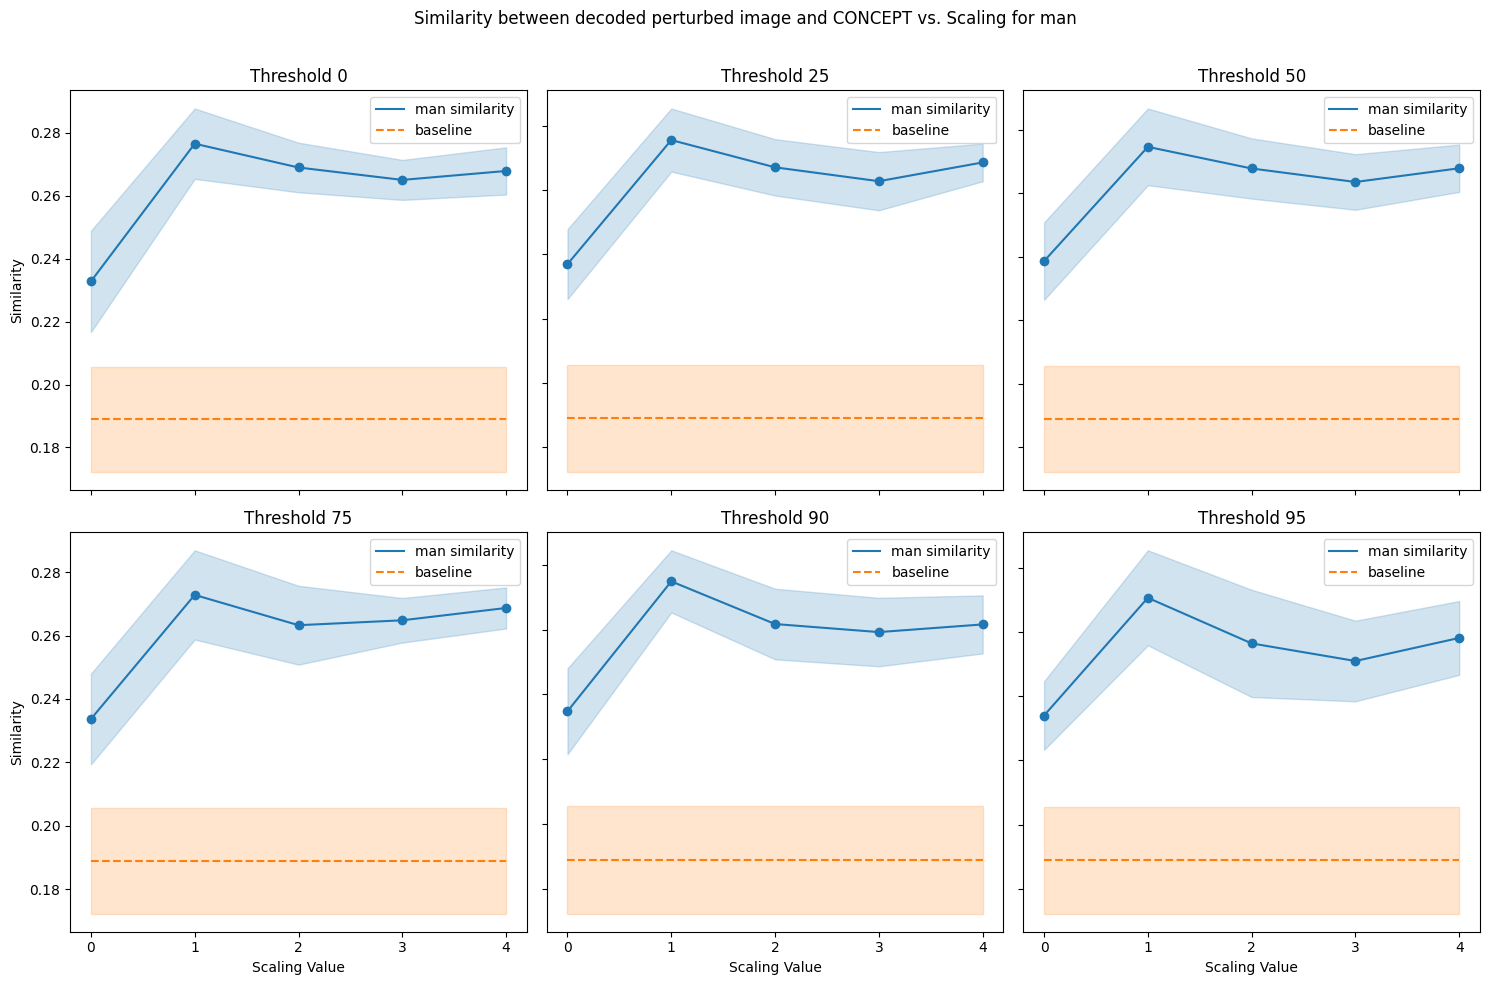

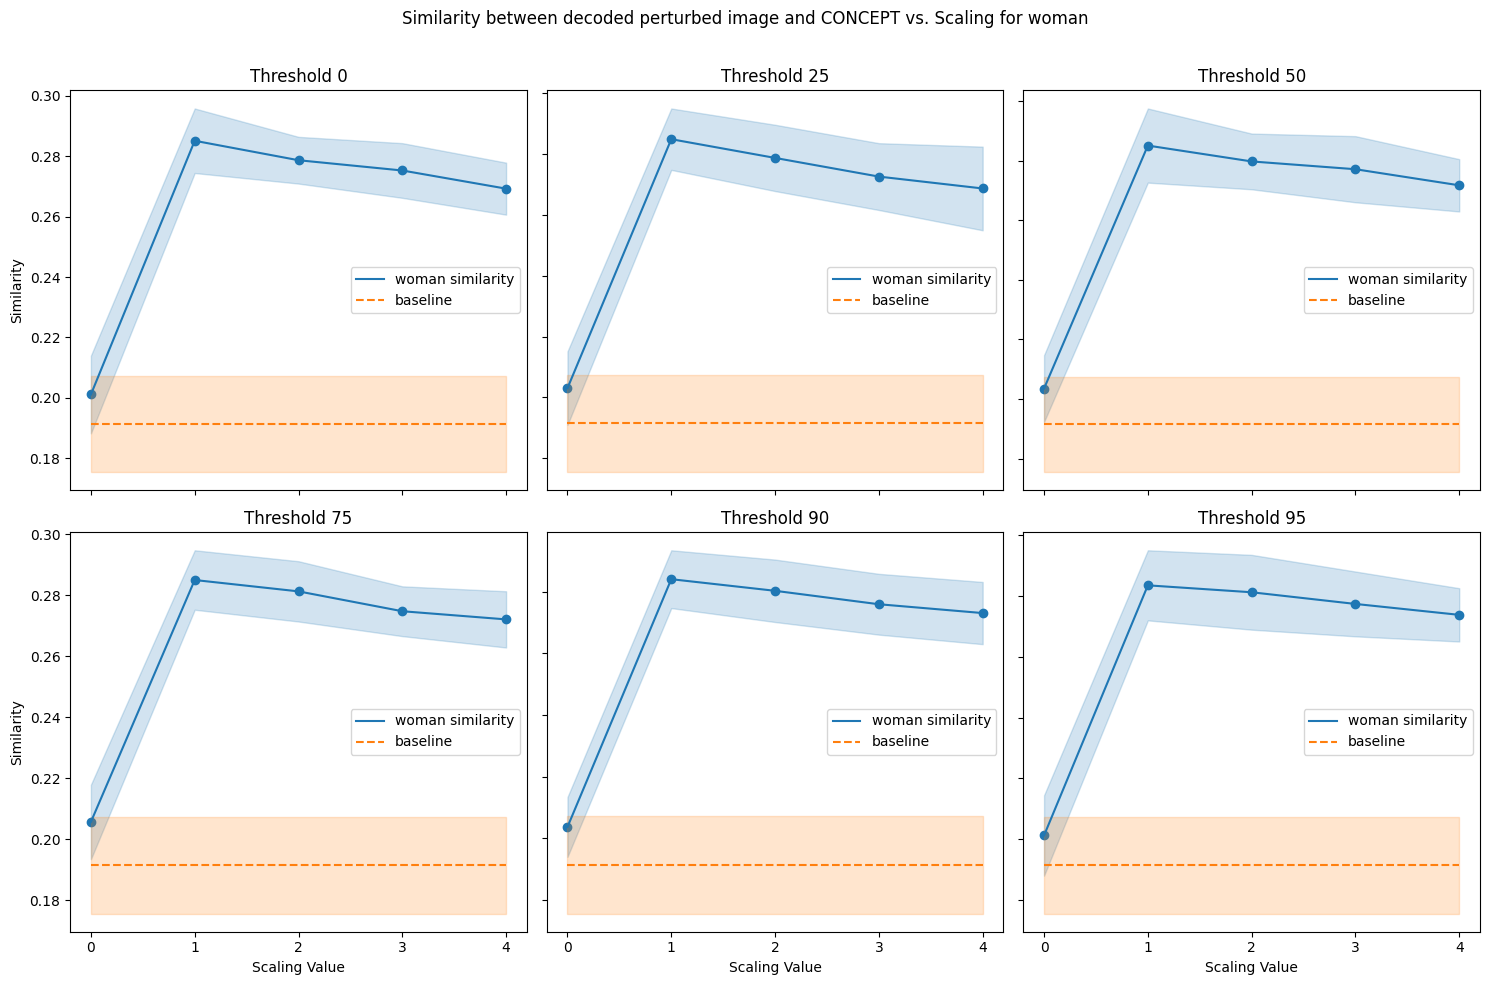

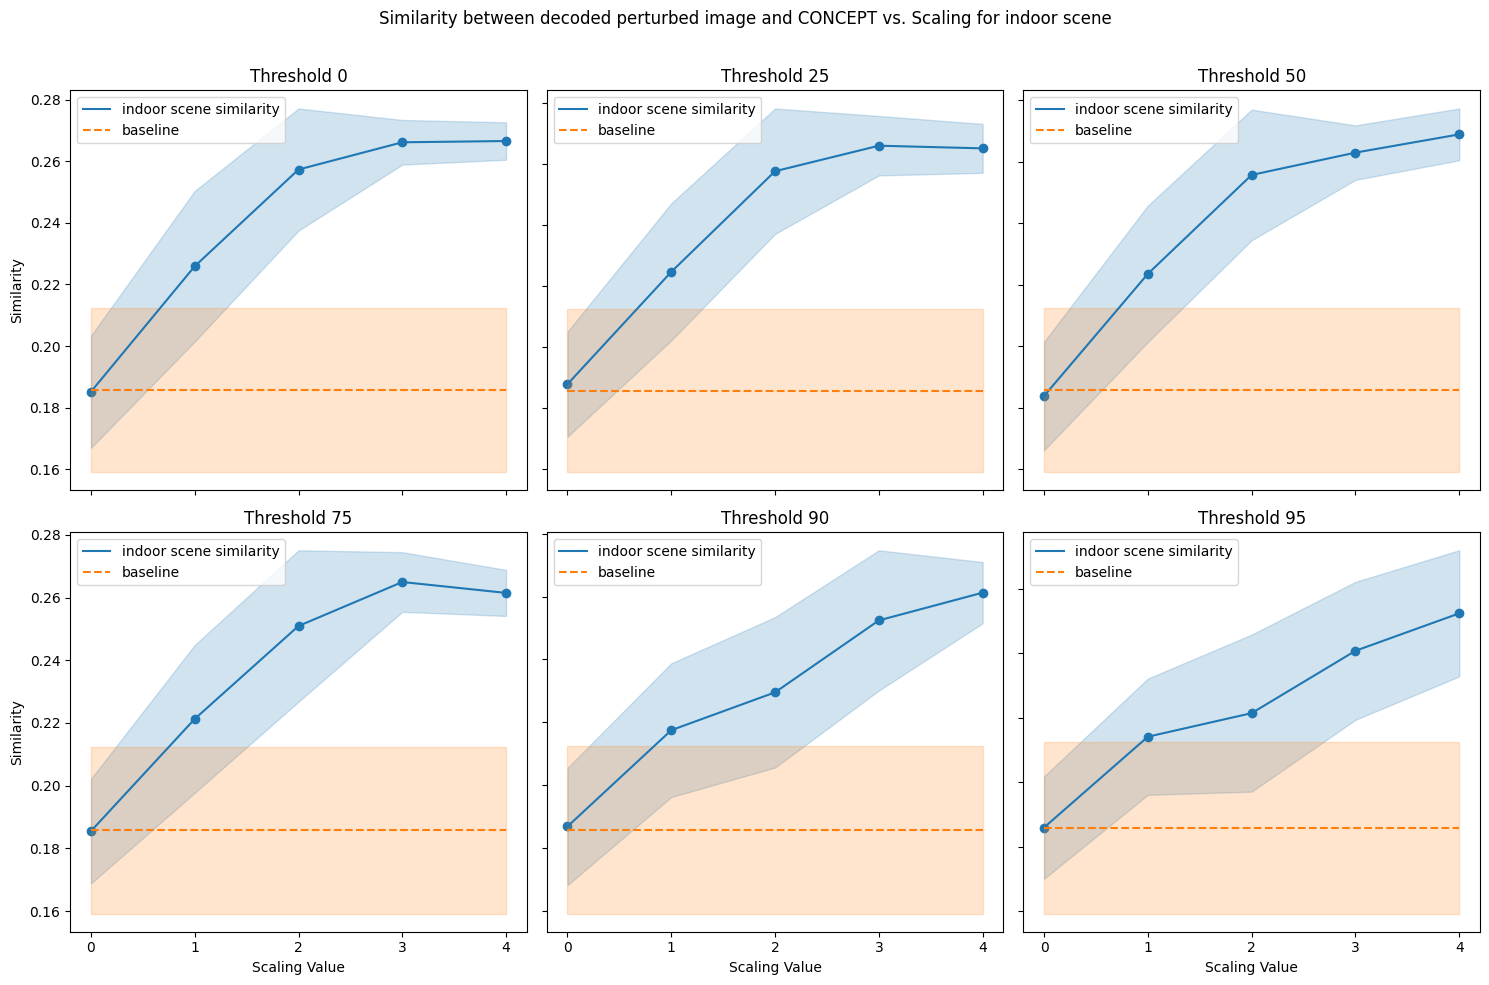

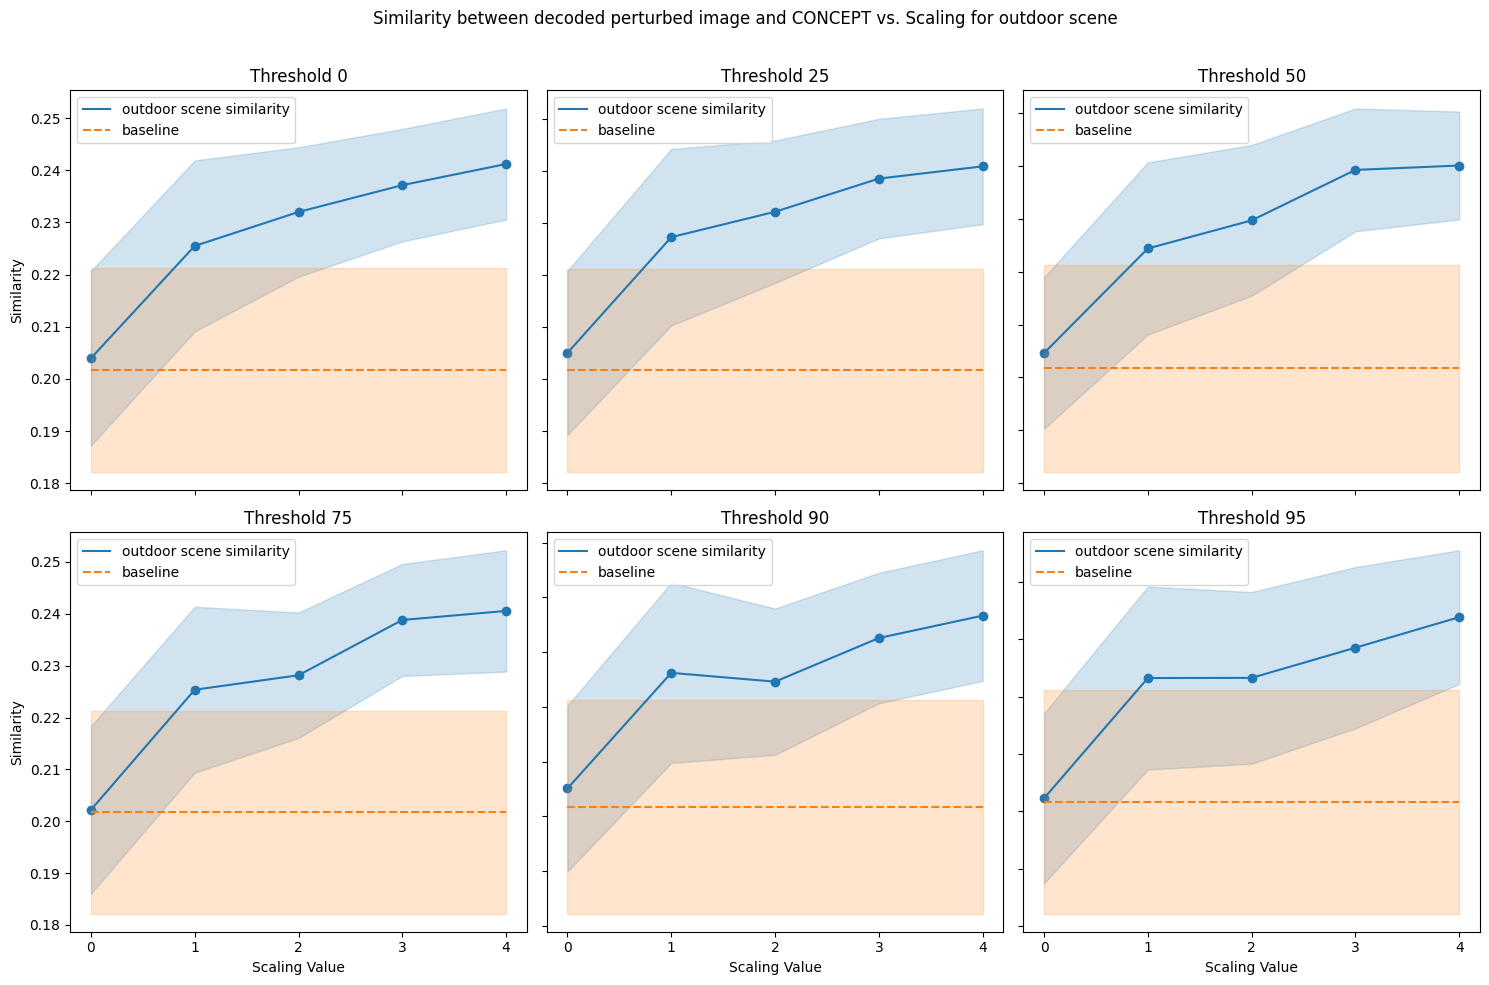

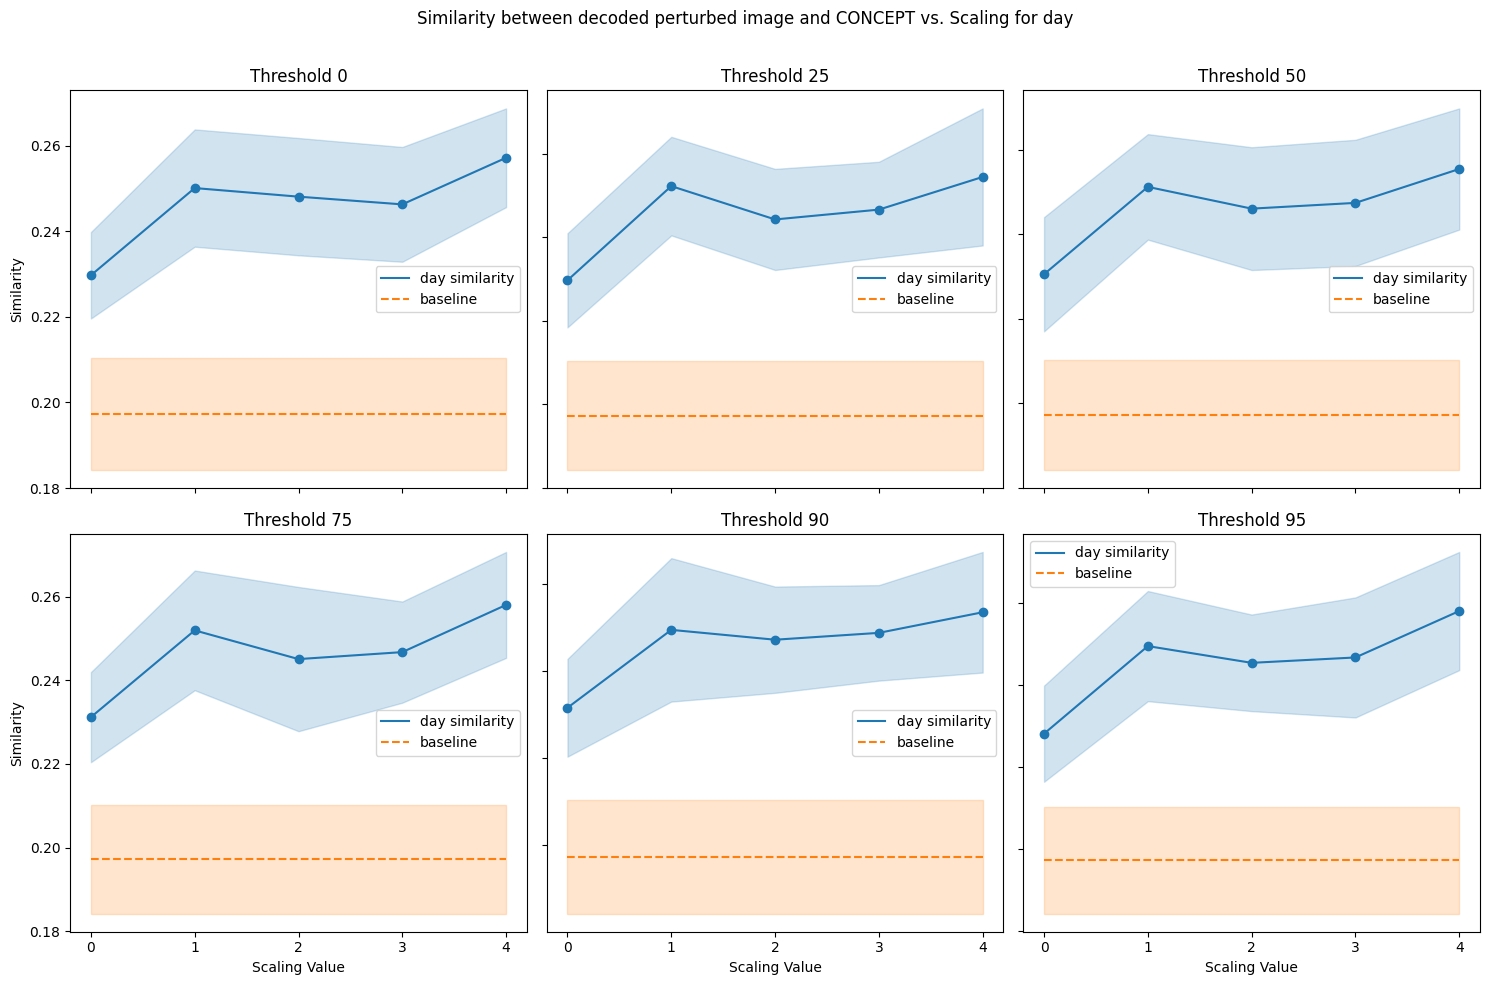

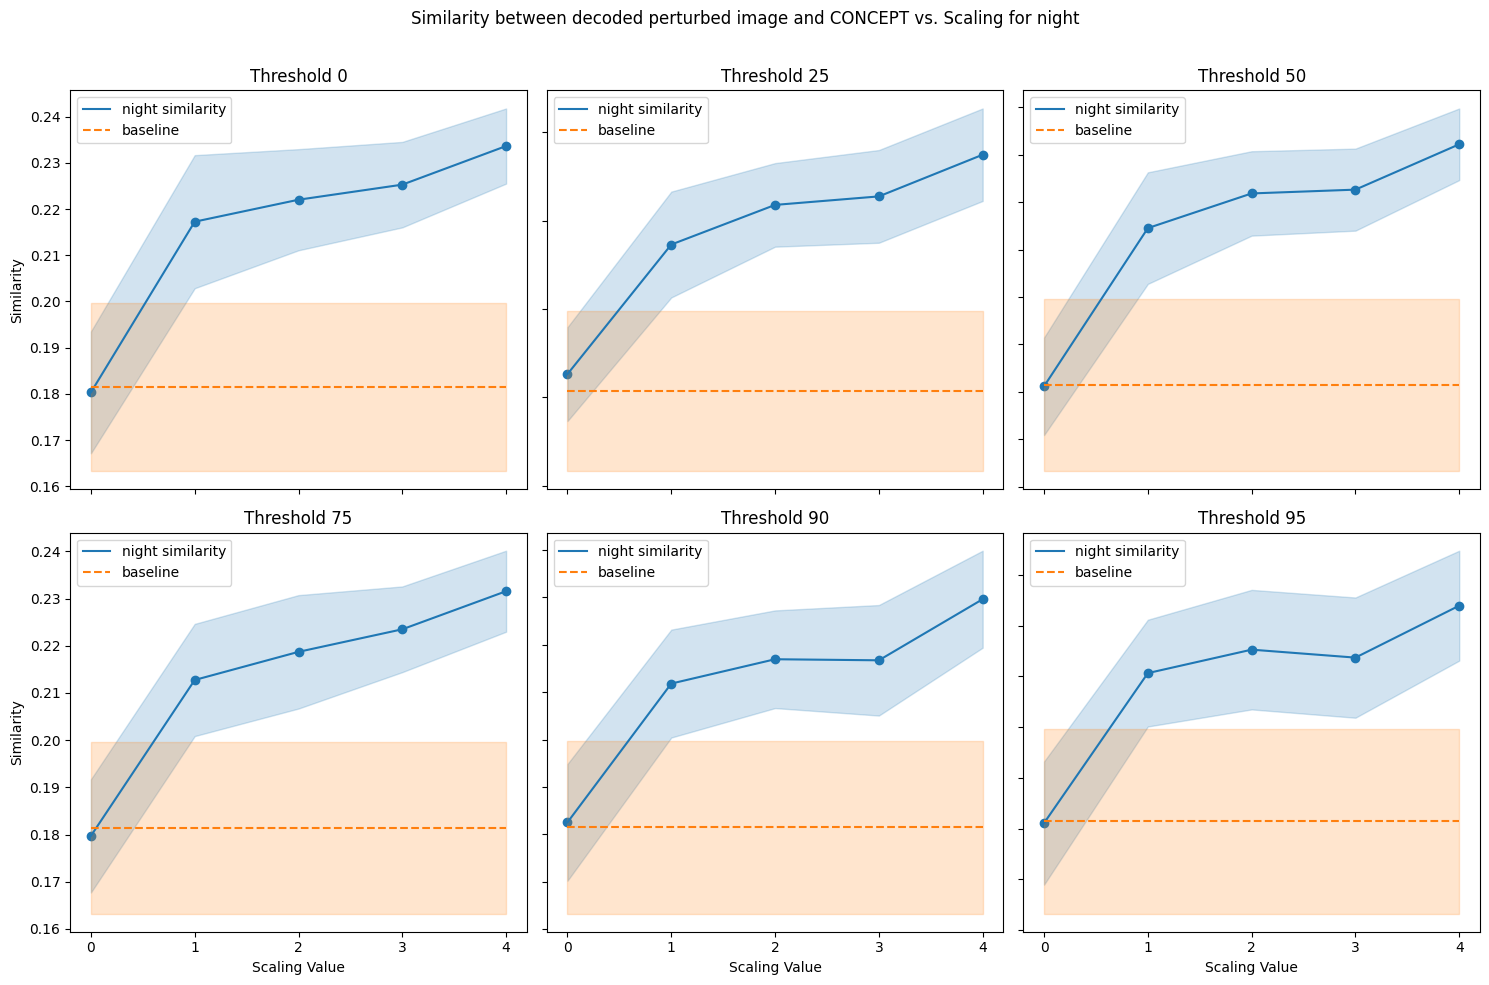

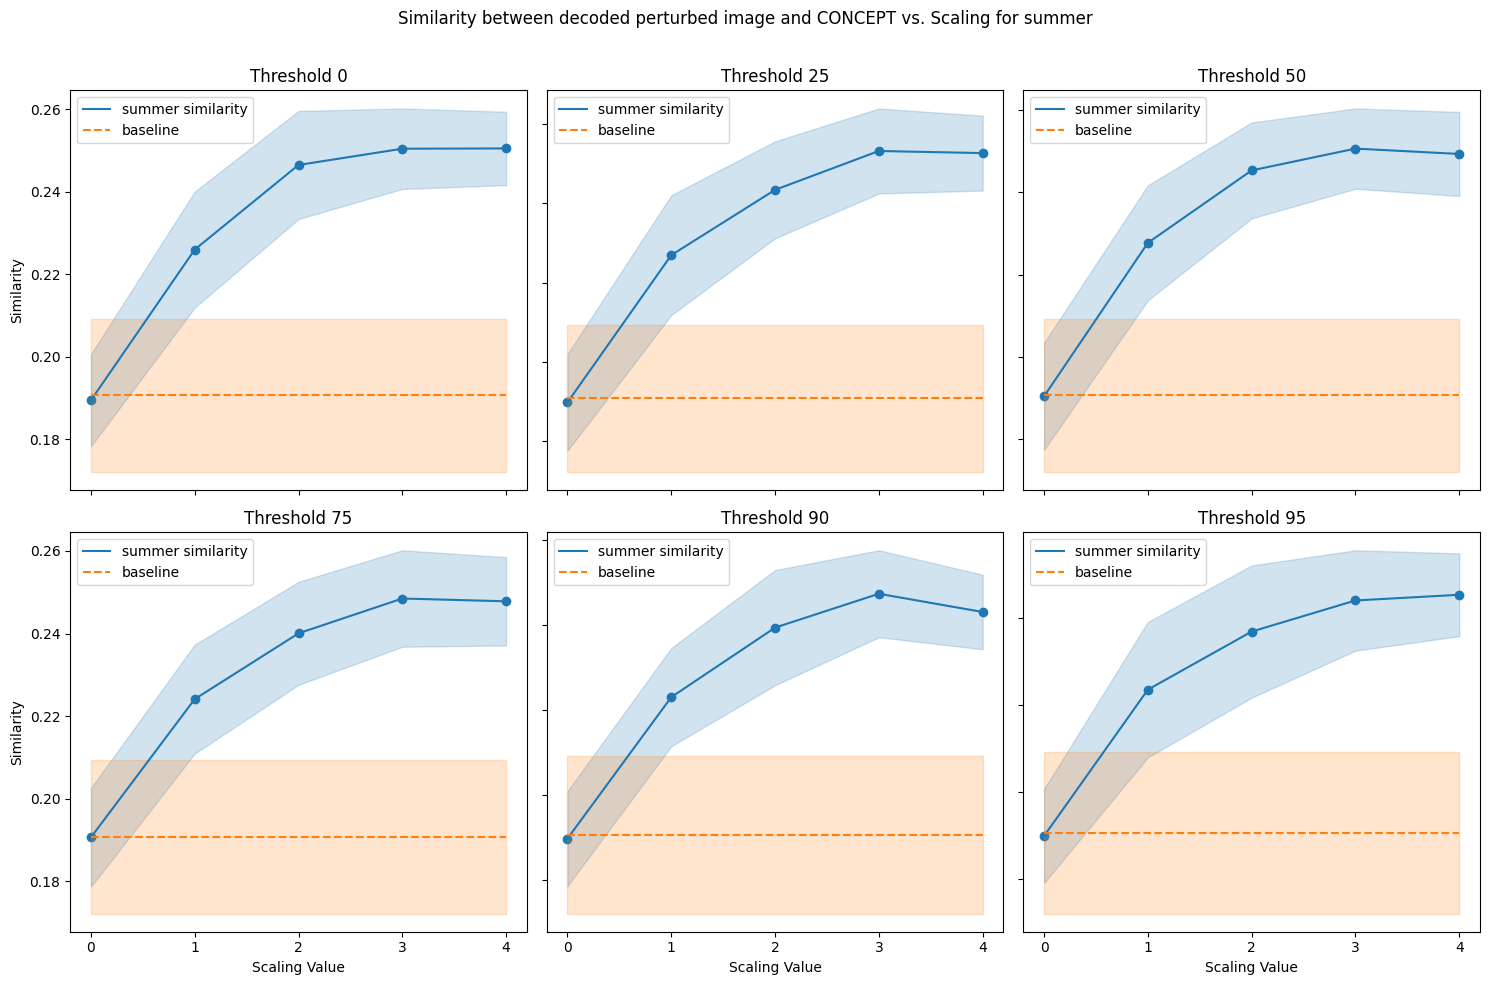

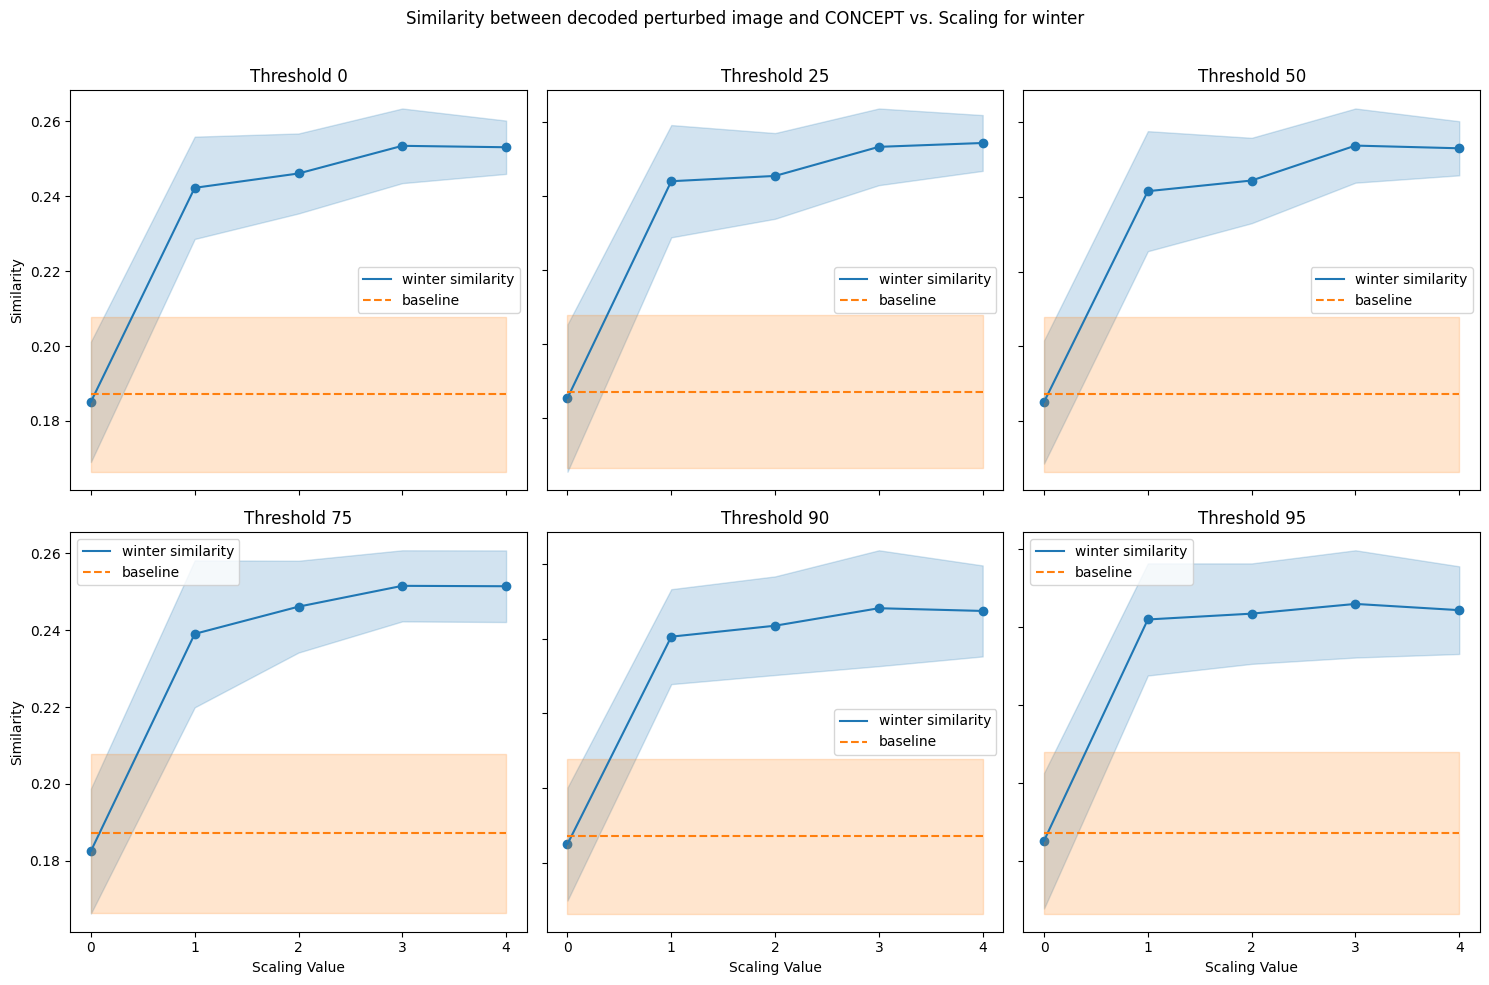

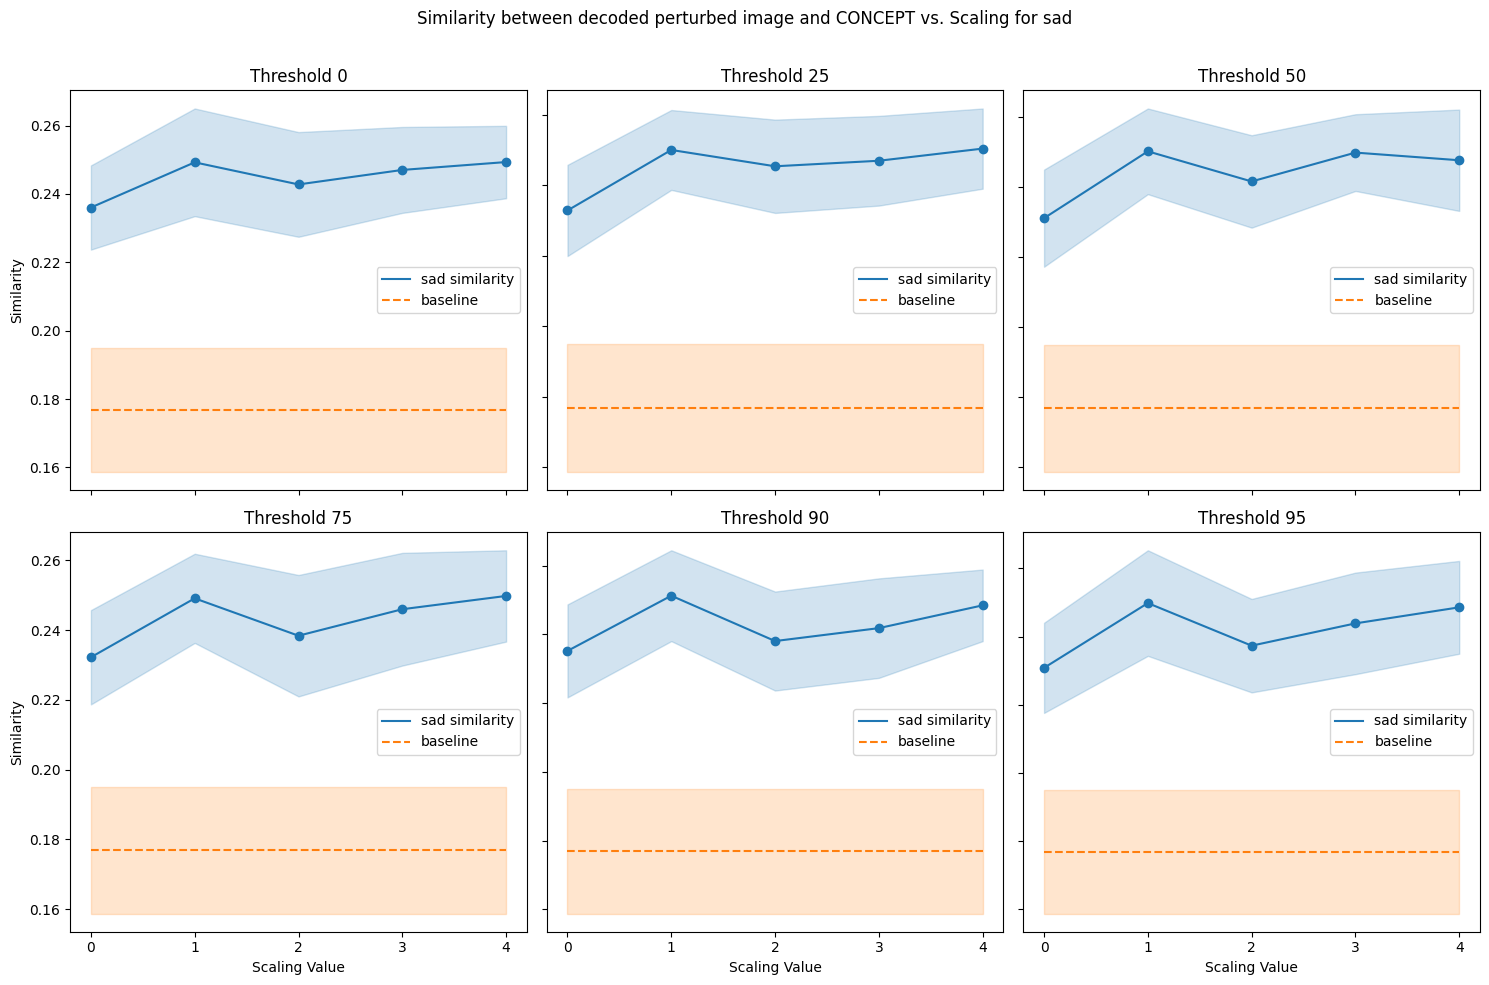

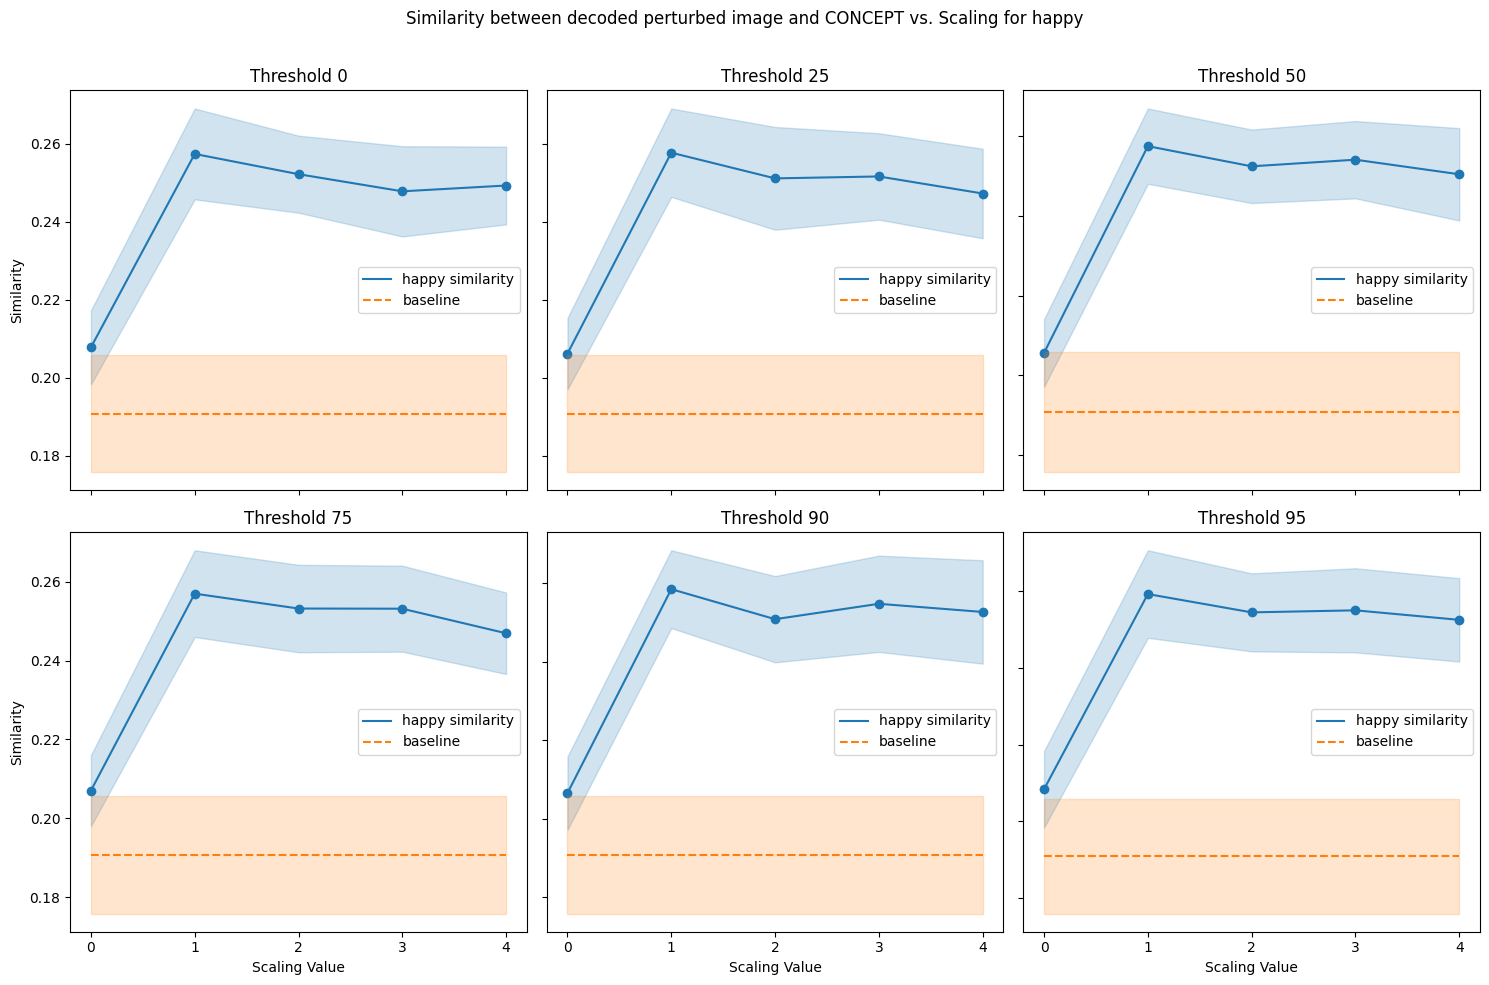

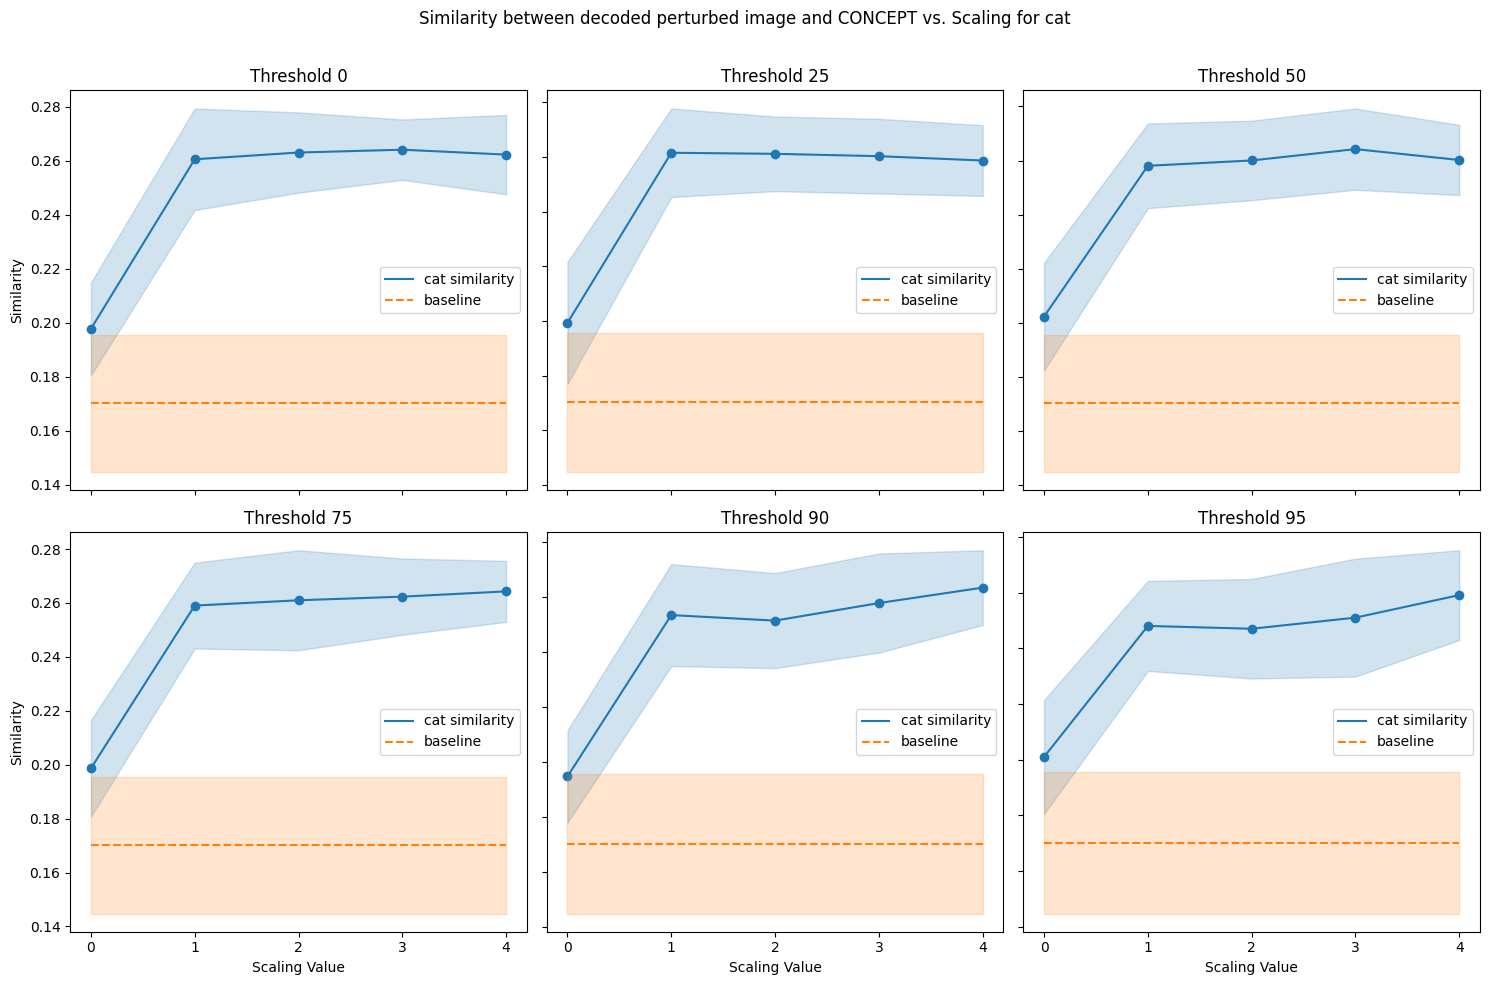

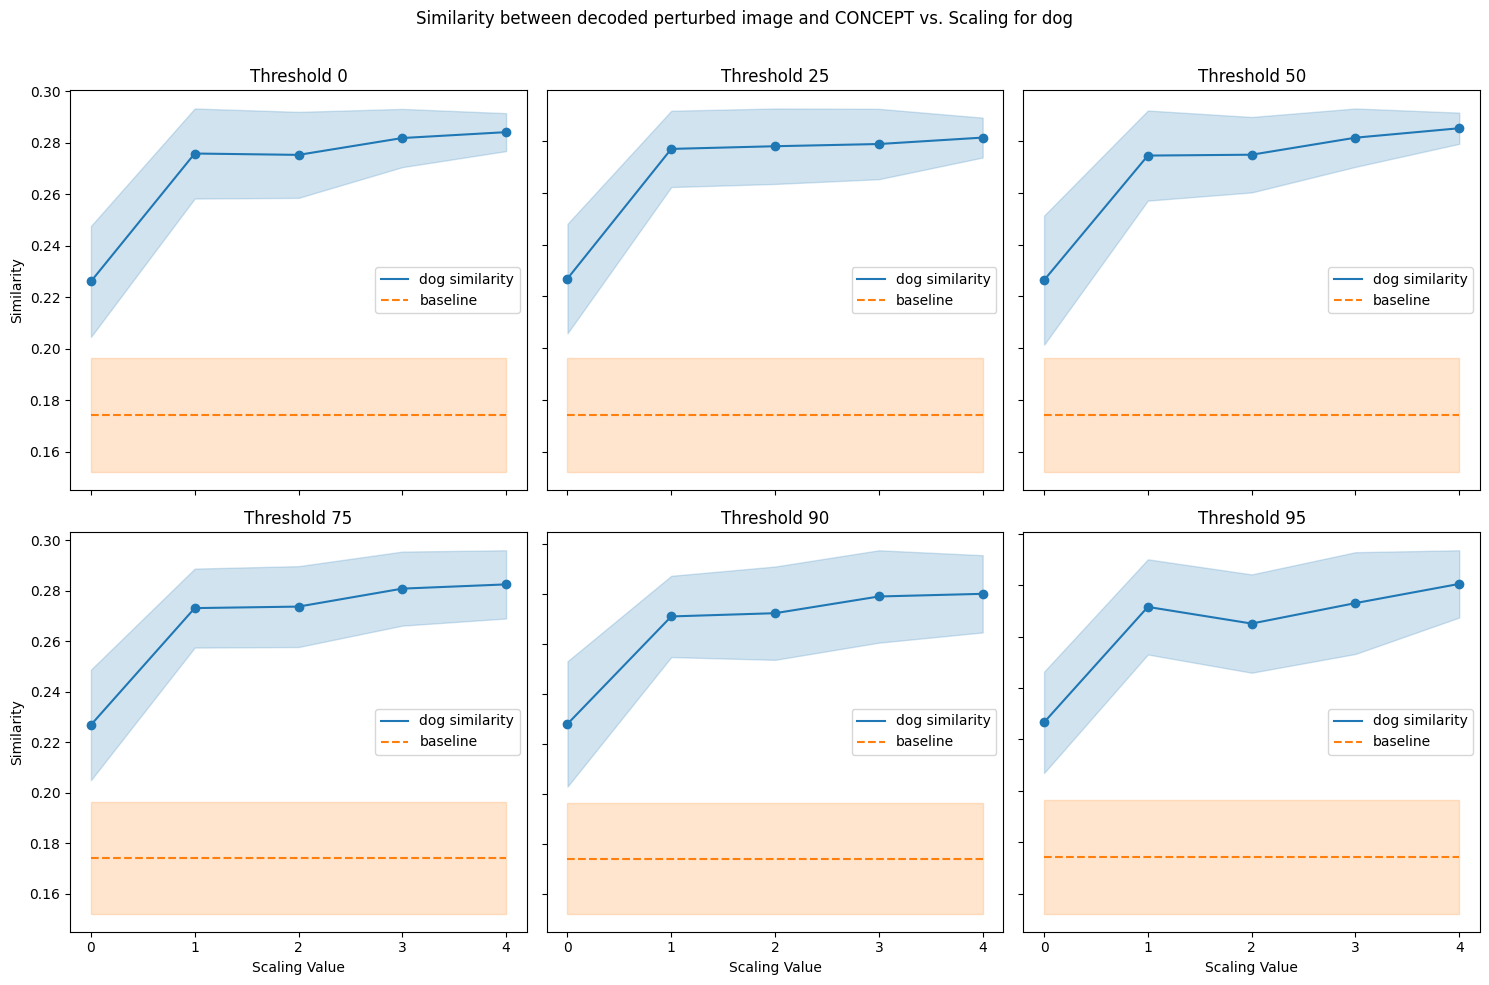

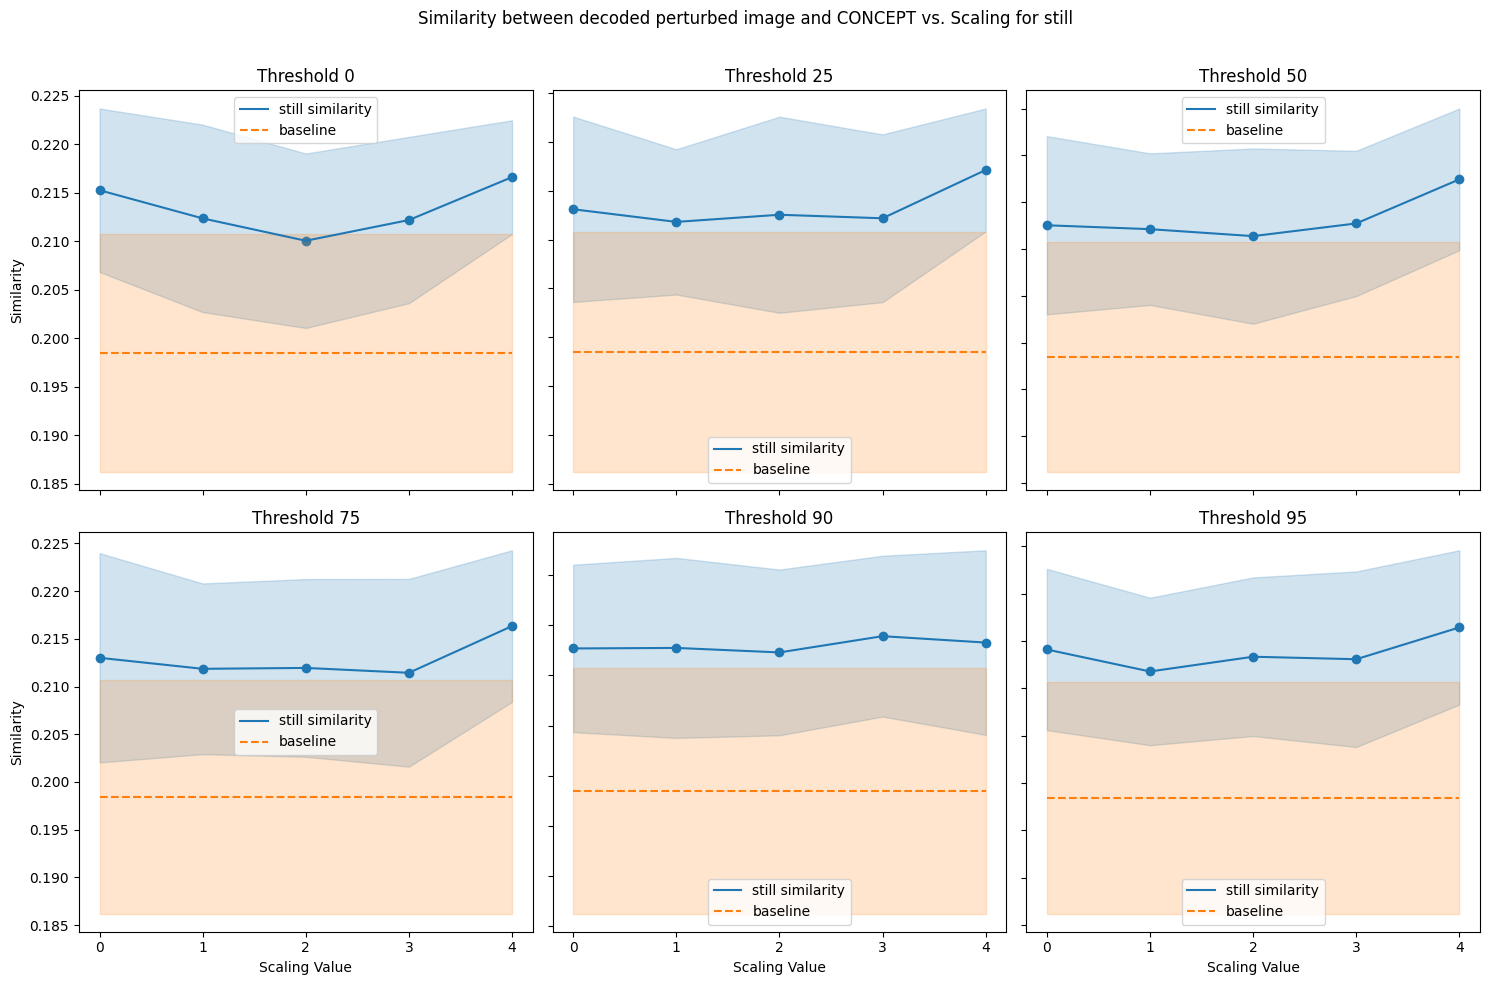

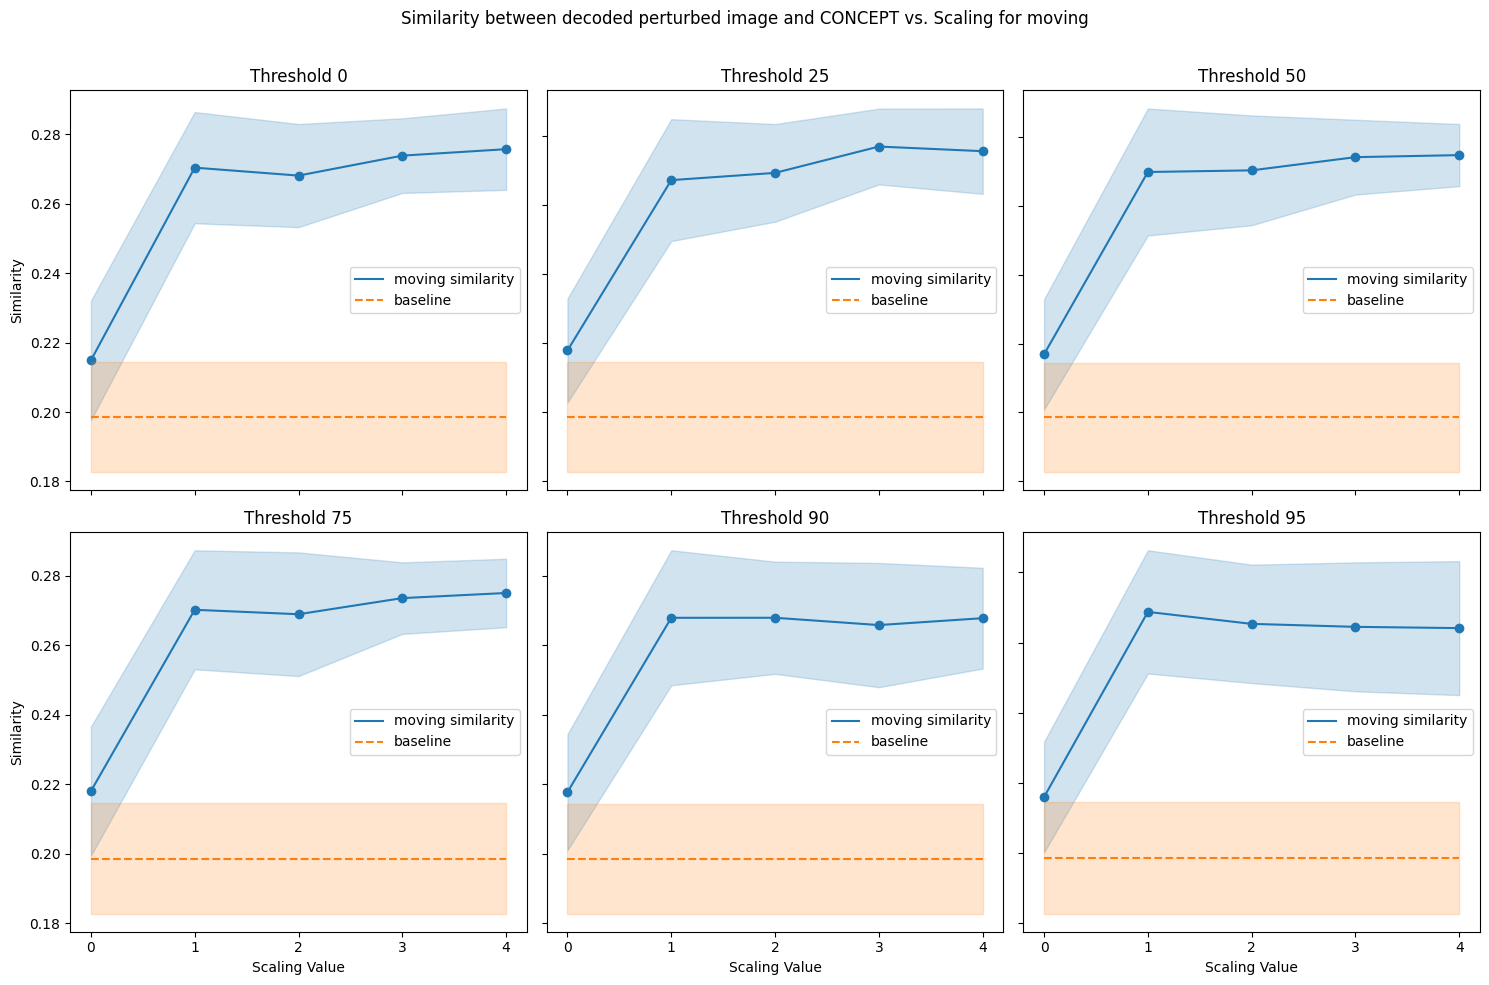

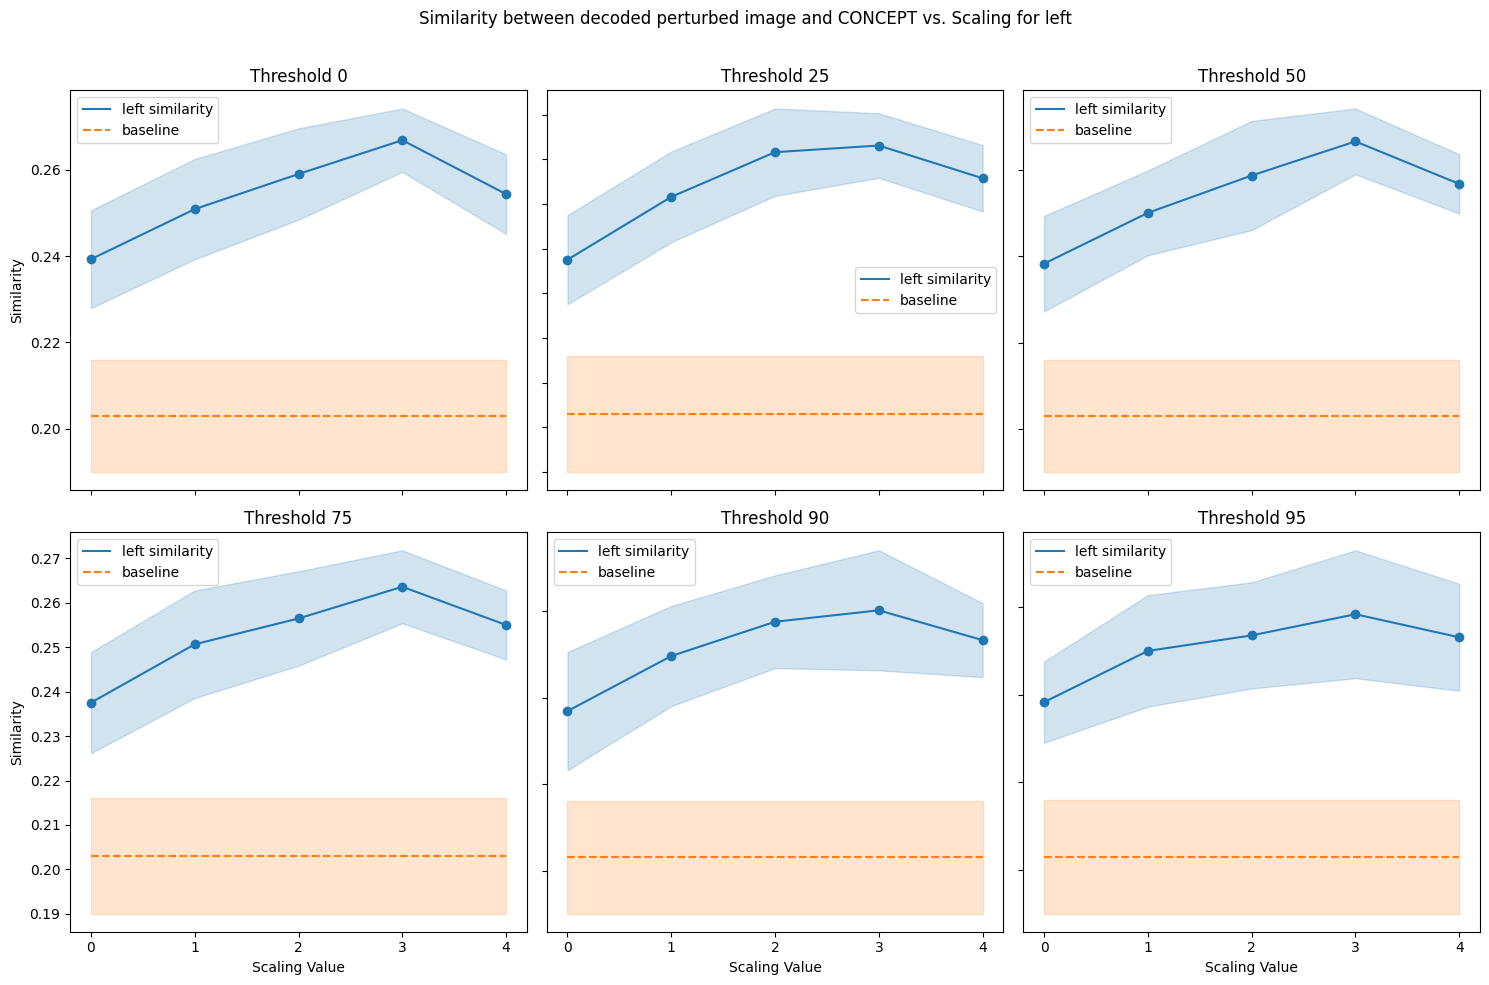

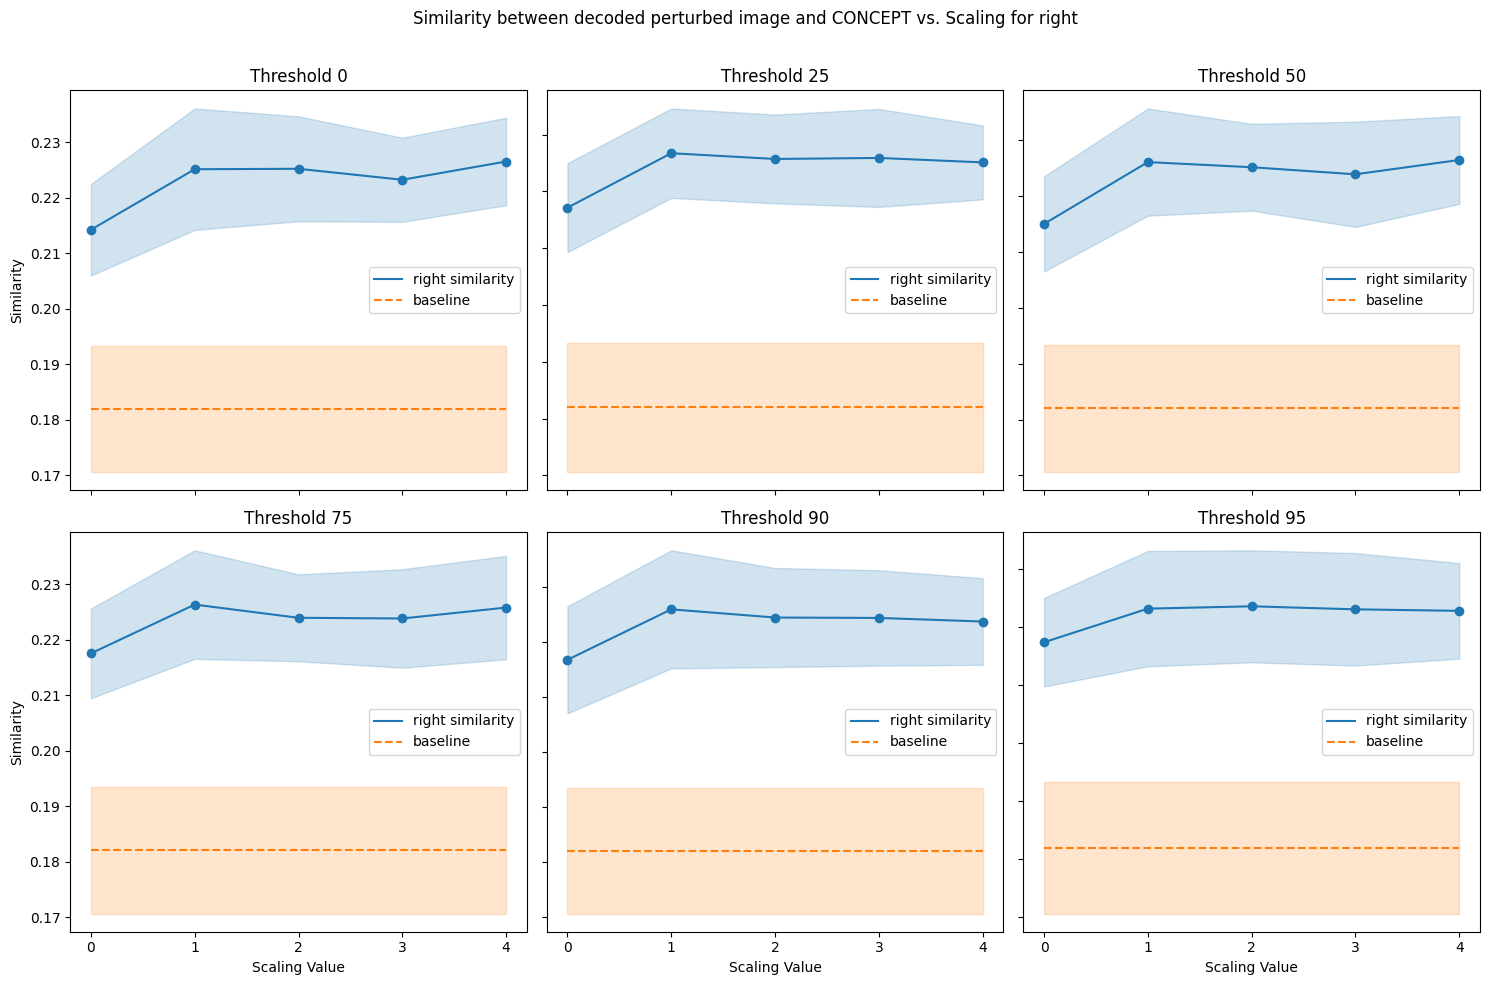

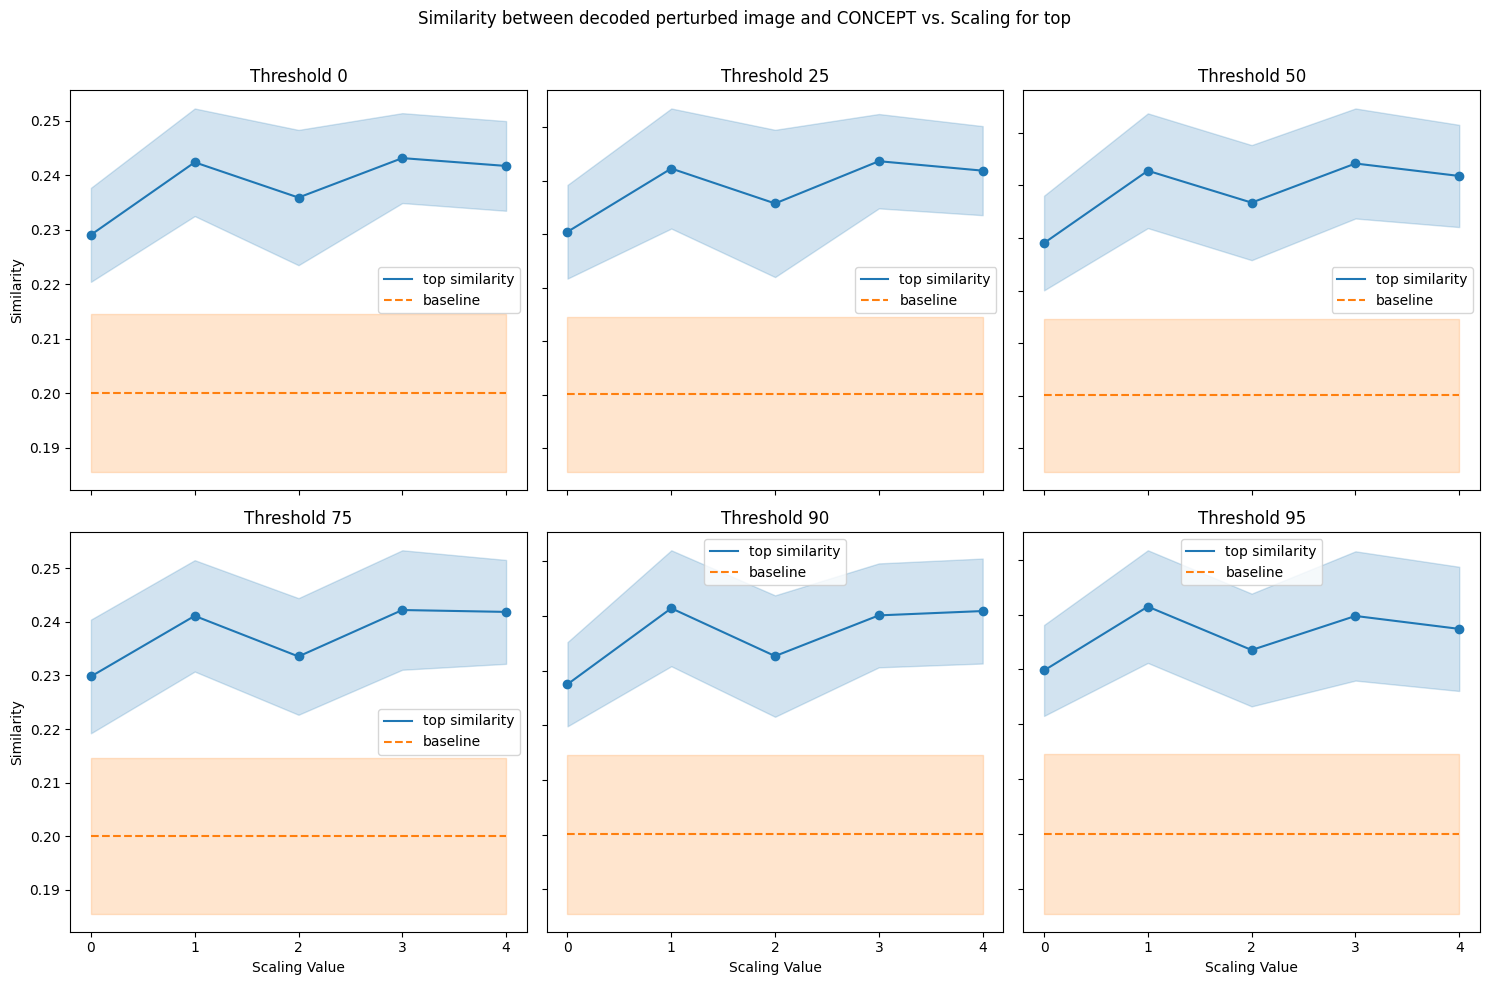

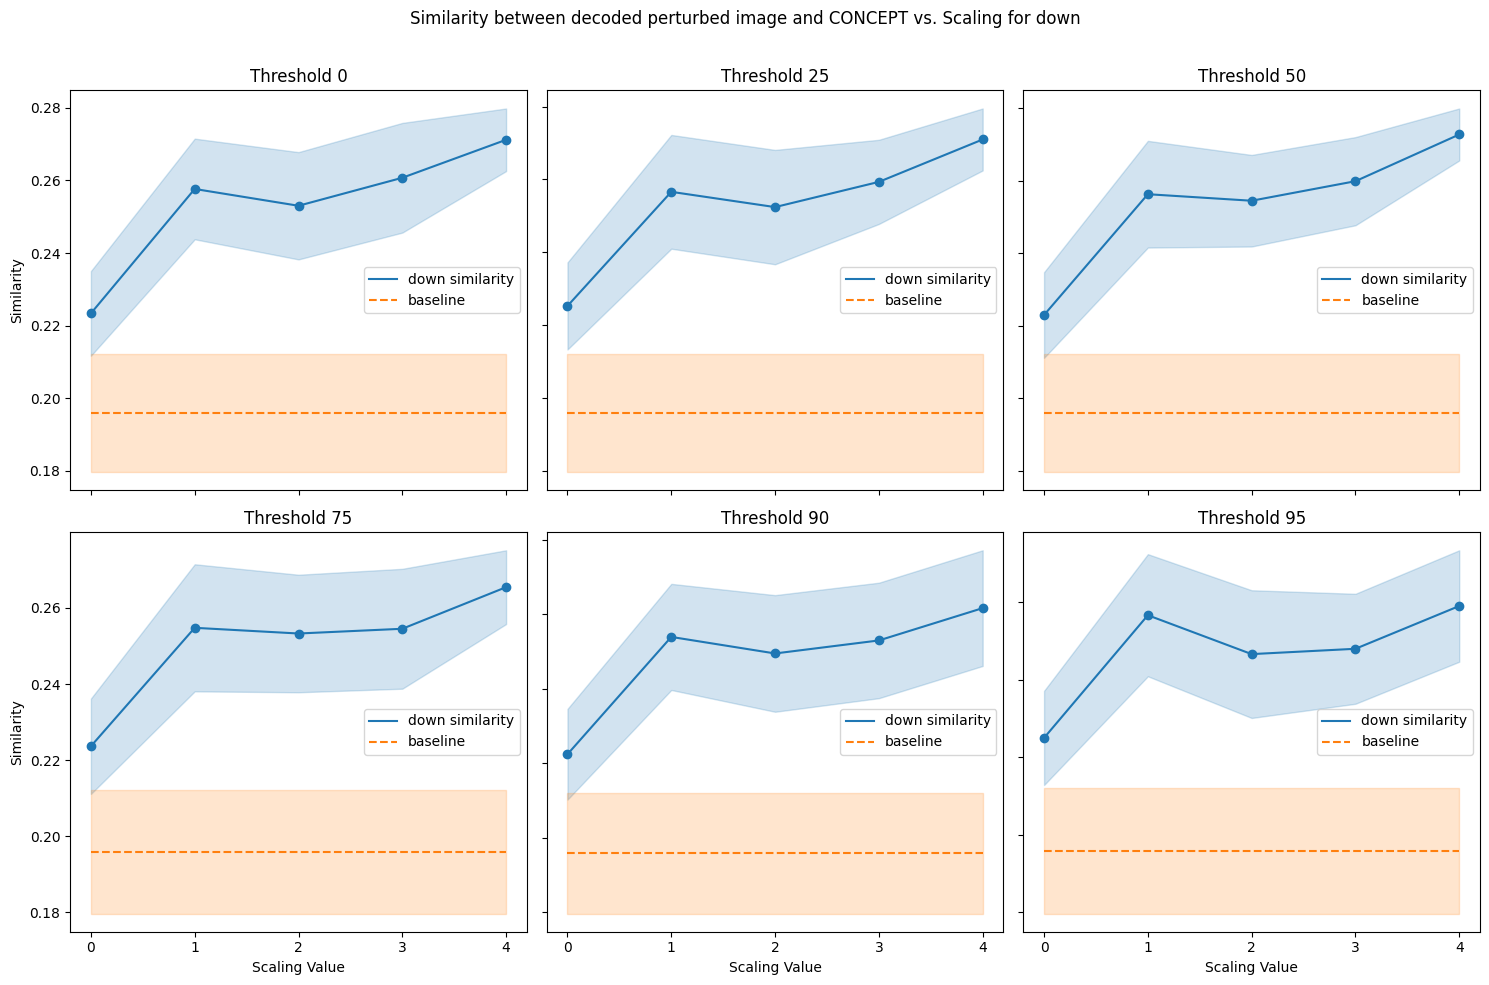

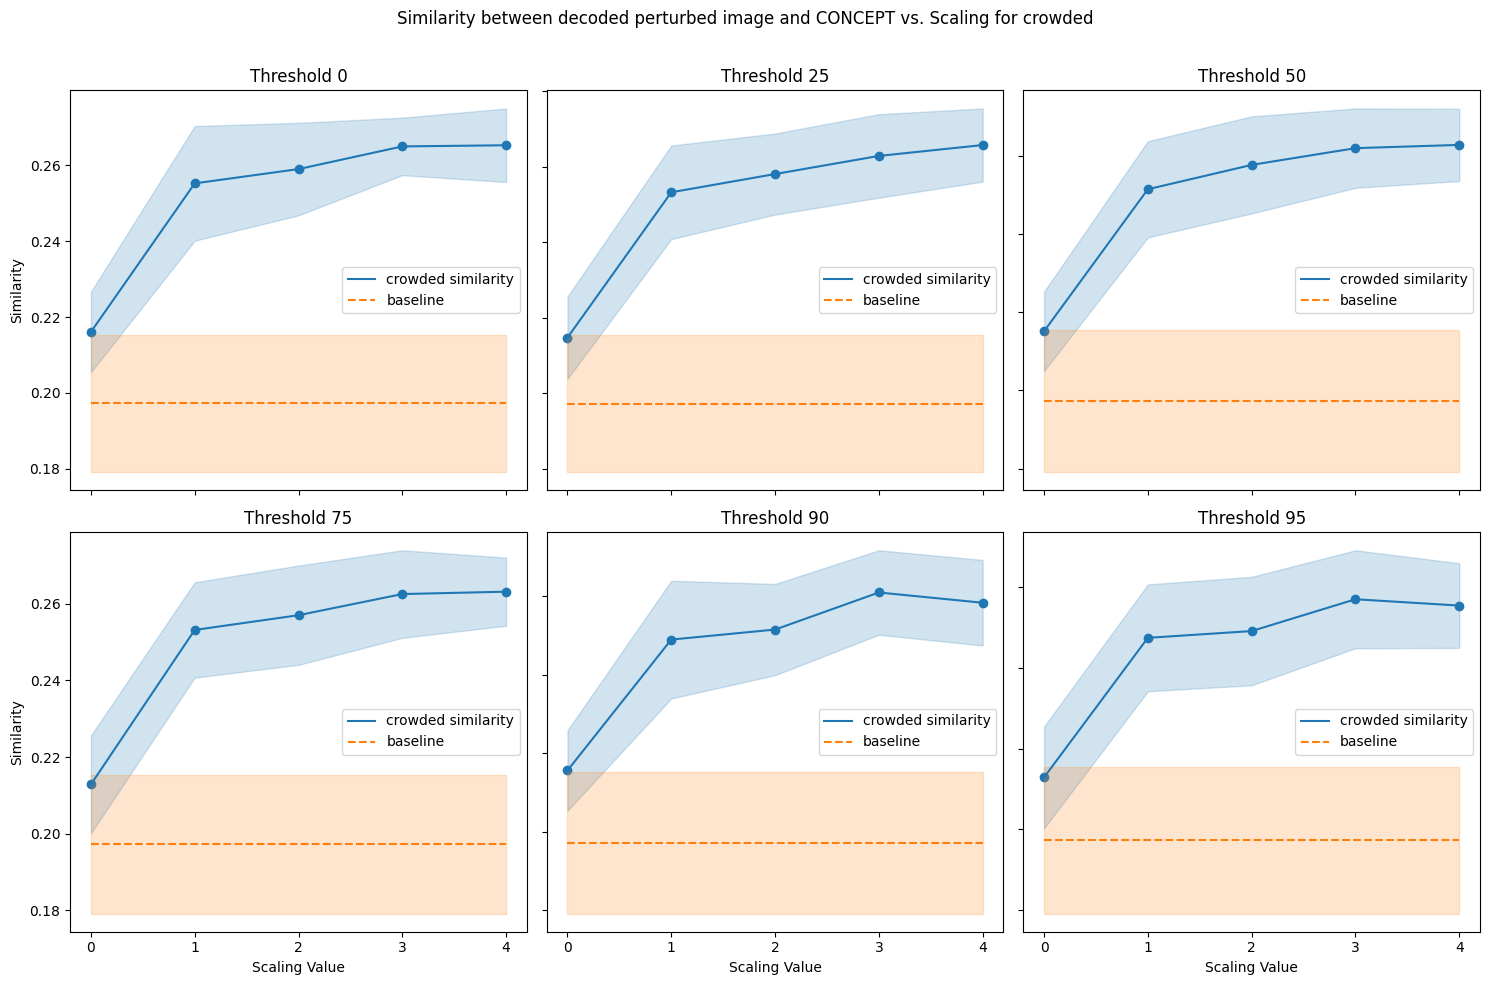

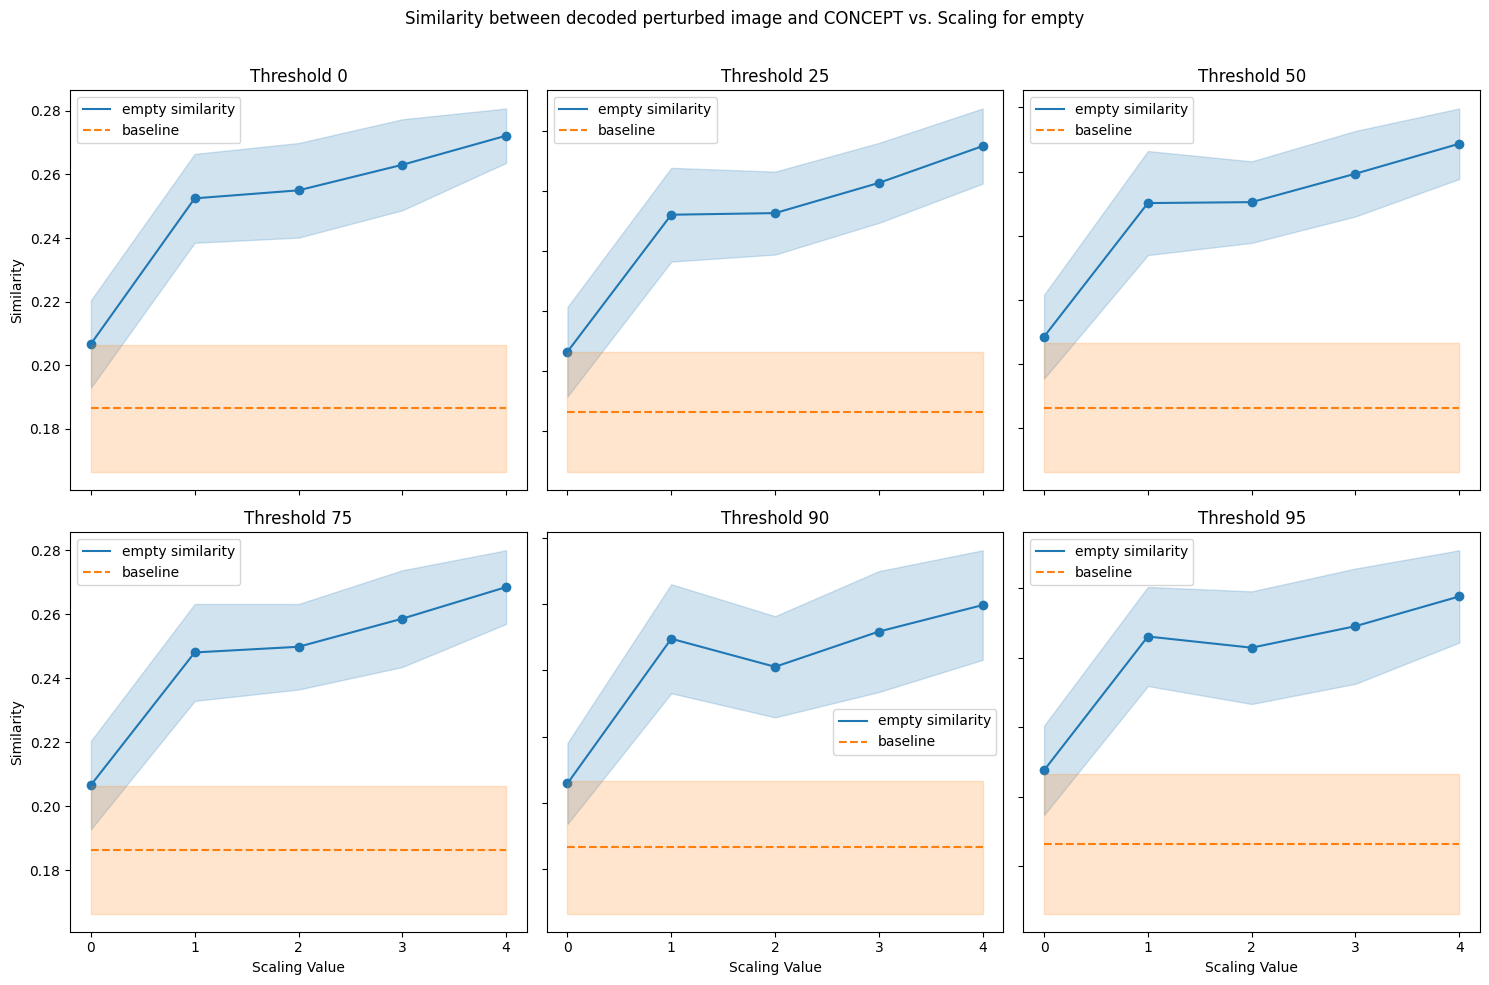

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
from os.path import join as opj
from scipy.special import softmax


results_dir =f"results_single/{sub}"
os.makedirs(results_dir,exist_ok=True)

# Updated plotting results
# scaling_values = [-4,-3,-2,-1,0,1,2,3,4]  # Corresponding scaling values without "original"
scaling_values = [0,1,2,3,4]
# all_keys = ["minus_seven", "minus_five", "minus_three", "minus_one", "original","plus_one", "plus_three", "plus_five", "plus_seven"]
all_keys =  ["original","plus_one", "plus_three", "plus_five", "plus_seven"]


# Define the number of columns and rows for subplots
n_cols = 3
n_rows = 2

## INDICES 0: concept, 1: stimulus image

for pair in unrolled_concepts:
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Similarity between decoded perturbed image and CONCEPT vs. Scaling for {pair}")

    for idx, thr in enumerate(thrs):
        row = idx // n_cols
        col = idx % n_cols

        y1_means = []
        y2_means = []
        y1_stds = []
        y2_stds = []

        for key in all_keys:
            img_embeds = all_results[thr][pair][key]  #similarity with concept!
            
            
            
            y1_means.append(img_embeds[:,0].mean())
            y2_means.append(img_embeds[:, 1].mean())
            y1_stds.append(img_embeds[:,0].std())
            y2_stds.append(img_embeds[:, 1].std())
            
        
        y1_means = np.array(y1_means)
        y2_means = np.array(y2_means)
        y1_stds = np.array(y1_stds)
        y2_stds = np.array(y2_stds)
        
            
        ##baseline correction
        # y1_means = y1_means - baselines[pair]["baseline_concept_similarities"].numpy()
        # y2_means = y2_means - baselines[pair]["baseline_img_similarities"].mean().numpy()
        # y1_means = softmax(y1_means)
        # y1_stds = softmax(y1_stds)
        
#         soft_values = softmax(np.stack([y1_means,y2_means],1),1)
#         y1_means = soft_values[:,0]
#         y2_means = soft_values[:,1]
        

        # Plot mean and fill area for standard deviation
        axs[row, col].plot(scaling_values, y1_means, label=f"{pair} similarity")
        axs[row, col].scatter(scaling_values, y1_means)
        
        axs[row, col].fill_between(scaling_values, 
                                   np.array(y1_means) - np.array(y1_stds), 
                                   np.array(y1_means) + np.array(y1_stds), alpha=0.2,color="tab:blue")
        
        axs[row,col].set_xticks(scaling_values)

                
            
        axs[row,col].hlines(baselines[pair]["baseline_concept_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:orange",label="baseline")

        
        axs[row, col].fill_between(x=scaling_values, y1=baselines[pair]["baseline_concept_similarities_mean"].mean()-baselines[pair]["baseline_concept_similarities_std"].mean(), 
                                   y2=baselines[pair]["baseline_concept_similarities_mean"].mean()+baselines[pair]["baseline_concept_similarities_std"].mean(),color="tab:orange",alpha=0.2)

#         axs[row, col].plot(scaling_values, y2_means, label=f"decoded image similarity")
#         axs[row, col].fill_between(scaling_values, 
#                                    np.array(y2_means) - np.array(y2_stds), 
#                                    np.array(y2_means) + np.array(y2_stds), alpha=0.2)
        
#         axs[row,col].hlines(baselines[pair]["baseline_img_similarities_mean"].mean(),xmin=0,xmax=4,linestyle="--",color="tab:orange",label="baseline")
#         axs[row, col].fill_between(x=scaling_values, y1=baselines[pair]["baseline_img_similarities_mean"].mean()-baselines[pair]["baseline_img_similarities_std"].mean(), 
#                                    y2=baselines[pair]["baseline_img_similarities_mean"].mean()+baselines[pair]["baseline_img_similarities_std"].mean(),color="tab:orange",alpha=0.2)

        axs[row, col].set_ylabel("Similarity")
        axs[row, col].set_title(f"Threshold {thr}")
        axs[row, col].legend()

        # Add arrows to indicate concept directions
        center = 0  # Index of 0 on the x-axis
#         axs[row, col].annotate("", xy=(4, 0.5), xytext=(0, 0.5),
#                                arrowprops=dict(arrowstyle="->",facecolor='black'),
#                                horizontalalignment='center', verticalalignment='center',
#                                fontsize=12, color='black')
#         axs[row, col].annotate(f"more {pair}",xy = (2,0.45),  xytext=(2, 0.45),
#                            horizontalalignment='center', verticalalignment='center',
#                            fontsize=12, color='black')
        
#         axs[row, col].annotate(f"", xy=(0, 0.5), xytext=(-4, 0.5),
#                                arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                                horizontalalignment='center', verticalalignment='center',
#                                fontsize=12, color='black')
#         axs[row, col].annotate(f"less {pair}", xy=(-2, 0.45), xytext=(-2, 0.45),
#                        arrowprops=dict(arrowstyle="<-",facecolor='black'),
#                        horizontalalignment='center', verticalalignment='center',
#                        fontsize=12, color='black')

    # Set common x-axis label
    for ax in axs.flat:
        ax.label_outer()  # Hide inner labels to avoid clutter

    axs[-1, 0].set_xlabel("Scaling Value")
    axs[-1, 1].set_xlabel("Scaling Value")
    axs[-1, 2].set_xlabel("Scaling Value")
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the main title
    plt.savefig(opj(results_dir, f"Similarity between decoded perturbed image and CONCEPT Scaling for {pair}.png"))
    plt.show()
    
    


In [20]:
# stop

In [21]:
img_embeds[:,0]

array([0.27177423, 0.2452179 , 0.2729033 , 0.24644649, 0.24730247,
       0.2770298 , 0.25850374, 0.2519555 , 0.26242653, 0.26999944,
       0.2785152 , 0.25662535, 0.26571807, 0.23218548, 0.26222292,
       0.23213848, 0.2574528 , 0.25106832, 0.2662769 , 0.26133645,
       0.26754344, 0.23665655, 0.27182662, 0.23525637, 0.24292833,
       0.26757836, 0.2602439 , 0.2448585 , 0.26897028, 0.26604095],
      dtype=float32)

## Display concepts added to images

In [22]:
unrolled_good = ['man',
 'woman',
 'indoor scene',
 'outdoor scene',
 'day',
 'night',
 'summer',
 'winter',
 'sad',
 'happy',
 'cat',
 'dog','crowded',
 'empty']

In [23]:
len(unrolled_good)

14

In [24]:
thrs

[0, 25, 50, 75, 90, 95]

In [25]:
# idx = 1
# thr = thrs[2]
# # Create a new figure
# fig, axes = plt.subplots(len(unrolled_good), len(coords_list) + 1, figsize=(20, 3* len(unrolled_good)))


# # for thr in thrs:
# for thr in [90,95]:
#     tgt_dir = opj(results_dir,f"{thr}")
#     os.makedirs(tgt_dir,exist_ok=True)

#     for idx in tqdm.trange(len(images)):
#         # Iterate over pairs and plot the images and cosine similarities
#         for i, pair in enumerate(unrolled_good):
#             # Load the original stimulus image
#             img = Image.open(f"models/{sub}/encoding/algebra_l2_SINGLE_thr_{thr}/fmri/{pair}_thr_{thr}/algebra_{idx}.png")
#             stim_image = img.crop(stim_coords)
#             cropped_images = []
#             for key, coords in coords_list.items():
#                 cropped_images.append(img.crop(coords))
#             # Plot the stimulus image in the first column
#             axes[i, 0].imshow(stim_image)
#             axes[i, 0].set_title(f"Perturbation\n{pair}", fontsize=10)
#             axes[i, 0].axis('off')
#             # print(len(cropped_images))
#             for j in range(len(cropped_images)):
#                 axes[i,j+1].imshow(cropped_images[j])
#                 axes[i,j+1].axis('off')
#             fig.suptitle(f"Img {idx} perturbed at thr {thr}")
#             # fig.tight_layout()
#             fig.savefig(opj(tgt_dir,f"{idx}.png"))
#                     # Clear the axes for the next set of images


In [26]:
print(results_dir)

results_single/subj07


In [27]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import tqdm
from joblib import Parallel, delayed

# Function to process a single image and save the figure
def process_image(thr, idx):
    tgt_dir = os.path.join(results_dir, f"{thr}")
    os.makedirs(tgt_dir, exist_ok=True)
    
    # Create a figure for each image
    fig, axes = plt.subplots(len(unrolled_good), len(coords_list) + 1, figsize=(20, 3 * len(unrolled_good)))
    
    for i, pair in enumerate(unrolled_good):
        img_path = f"models/{sub}/encoding/algebra_l2_SINGLE_thr_{thr}/fmri/{pair}_thr_{thr}/algebra_{idx}.png"
        img = Image.open(img_path)
        
        stim_image = img.crop(stim_coords)
        cropped_images = [img.crop(coords) for coords in coords_list.values()]
        
        axes[i, 0].imshow(stim_image)
        axes[i, 0].set_title(f"Perturbation\n{pair}", fontsize=10)
        axes[i, 0].axis('off')
        
        for j, cropped_img in enumerate(cropped_images):
            axes[i, j + 1].imshow(cropped_img)
            axes[i, j + 1].axis('off')
    
    fig.suptitle(f"Img {idx} perturbed at thr {thr}")
    fig.savefig(os.path.join(tgt_dir, f"{idx}.png"))
    
    # Clear and close the figure to free up resources
    plt.close(fig)


num_jobs = 30  # Use all available CPUs

# List to hold all (thr, idx) pairs for processing
tasks = [(thr, idx) for thr in thrs for idx in range(len(images))]

# Run the process_image function in parallel using joblib
Parallel(n_jobs=num_jobs)(delayed(process_image)(thr, idx) for thr, idx in tqdm.tqdm(tasks))



  0%|                                                                                                                                | 0/180 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [28]:
print("fine", results_dir)

fine results_single/subj07
